=== Using single directory with signature-optimized augmentations ===
Found 5623 valid image-mask pairs
Total samples: 5623
Train samples: 4499
Validation samples: 1124
Validation split: 20.0%
Using signature-optimized augmentations
Created subset with 4499 samples from indices
Created subset with 1124 samples from indices
Training samples: 4499
Validation samples: 1124
Analyzing dataset...

Dataset Analysis:
Total pixels analyzed: 26,214,400
Classes found: [np.int64(0), np.int64(1)]
Class 0: 22,104,056 pixels (84.32%)
Class 1: 4,110,344 pixels (15.68%)

Class weights (inverse_freq):
Class 0: 0.5930
Class 1: 3.1888
Split info saved to ./split_info/

Testing data loading...
=== Training Loader ===
Batch 0:
  Images shape: torch.Size([8, 3, 512, 512])
  Masks shape: torch.Size([8, 512, 512])
  Unique classes in batch: tensor([0, 1])
  Sample filenames: ['signature_6224.png', 'signature_6058.png', 'signature_3085.png']
Batch 1:
  Images shape: torch.Size([8, 3, 512, 512])
  Masks shape: t

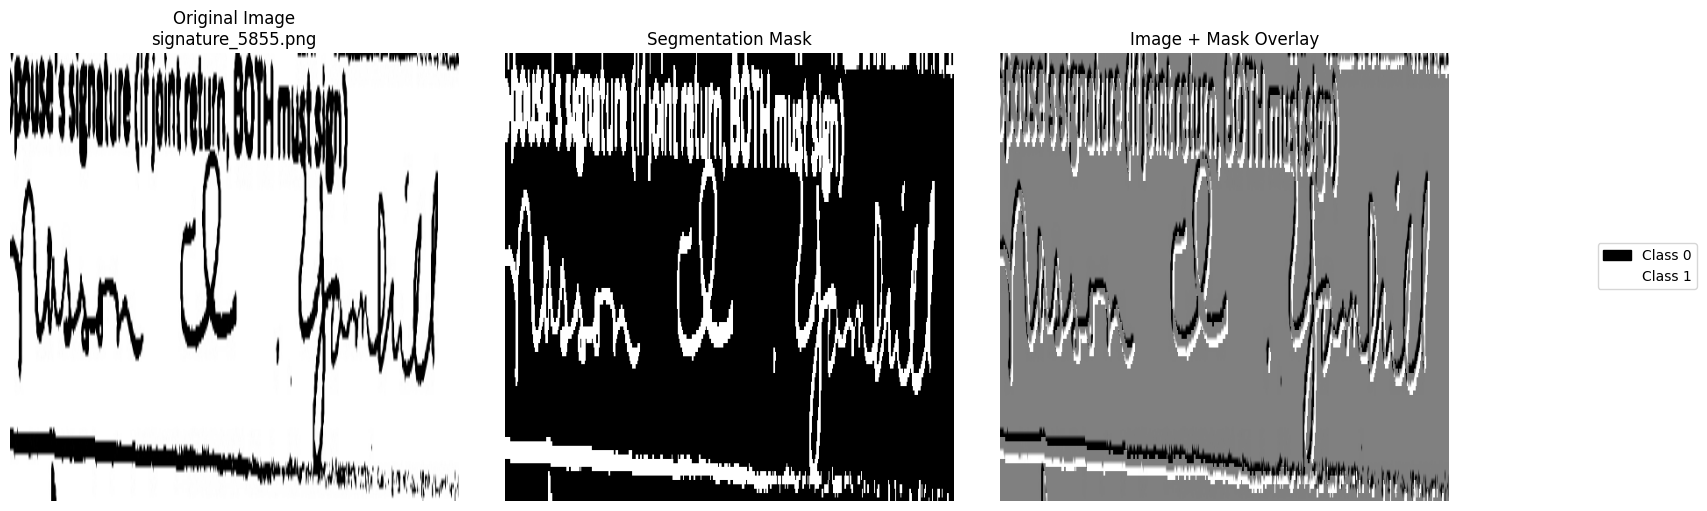


Sample Info:
Filename: signature_5855.png
Image shape: (512, 512, 3)
Mask shape: (512, 512)
Unique classes: [0 1]
Class distribution: [(np.int64(0), np.int64(210511)), (np.int64(1), np.int64(51633))]

2. Visualizing random samples from training set...
Random samples visualization saved to random_samples.png


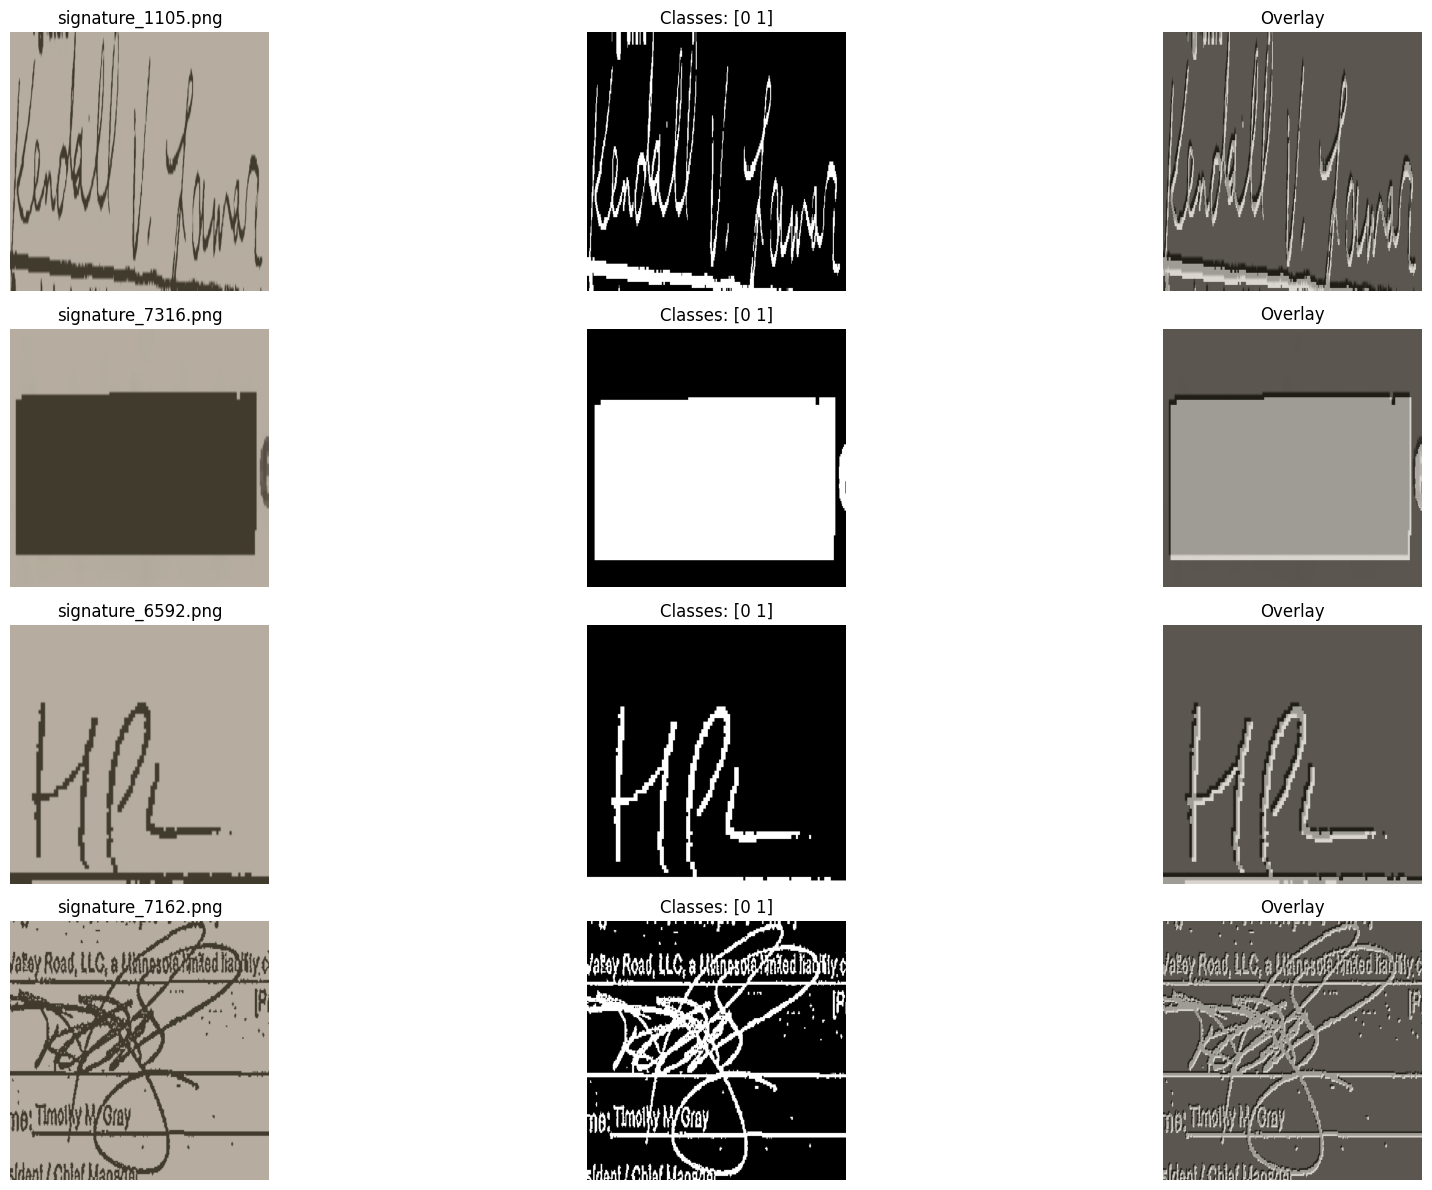


3. Visualizing batch from training loader...
Batch visualization saved to batch_visualization.png


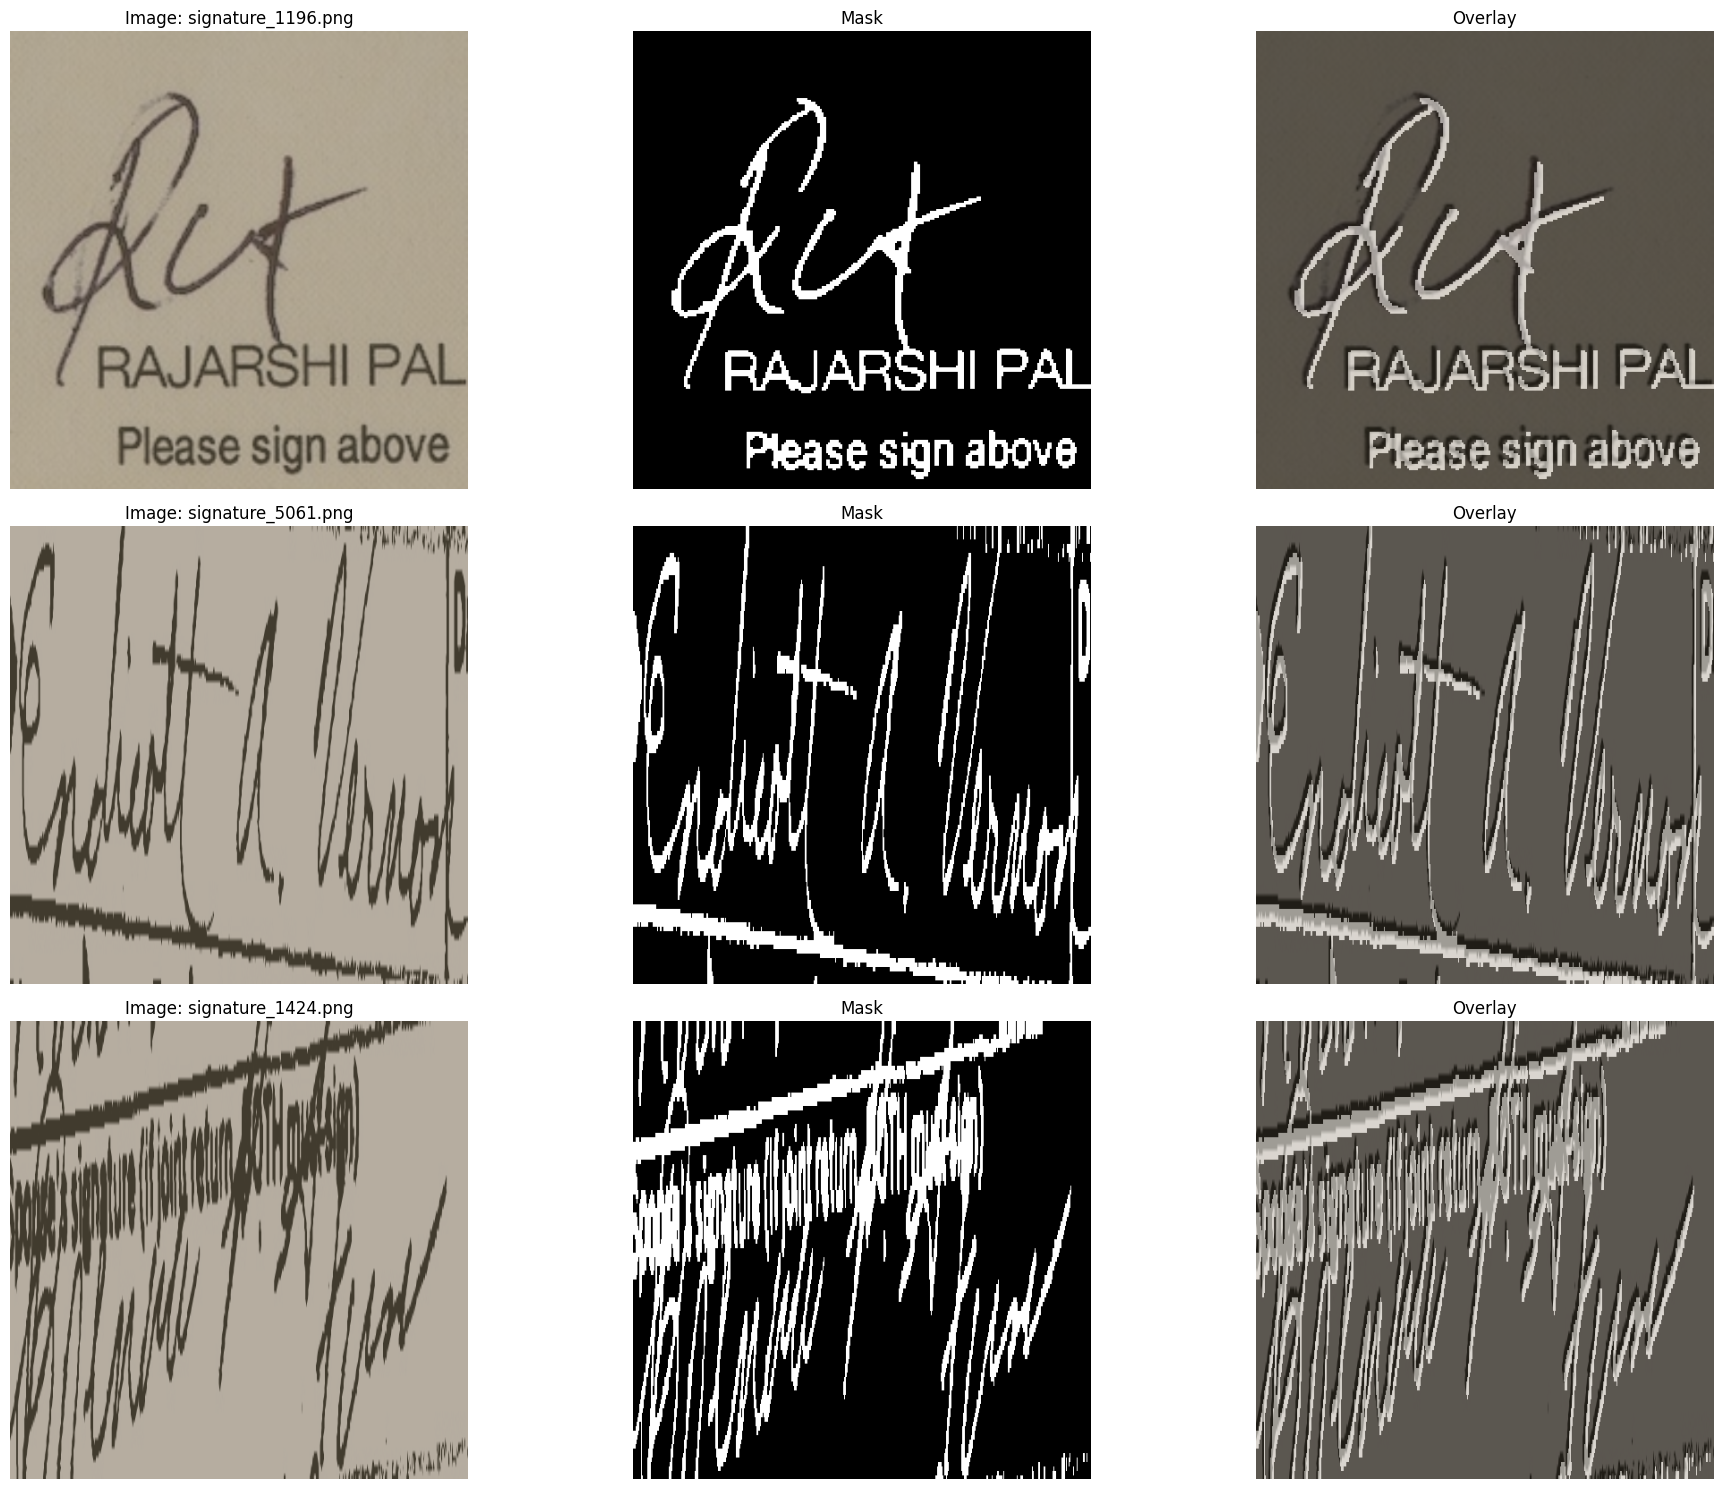

In [9]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from pathlib import Path
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import random

class SegmentationDatasetWithIndices(Dataset):
    def __init__(self, image_dir, mask_dir, indices, transform=None, image_size=(512, 512)):
        """
        Dataset for image segmentation with specific indices (for train/val split)
        
        Args:
            image_dir: Directory containing input images
            mask_dir: Directory containing segmentation masks
            indices: List of indices to use from the full dataset
            transform: Albumentations transform pipeline
            image_size: Target size for images (height, width)
        """
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.image_size = image_size
        
        # Get all image files
        all_image_files = sorted([f for f in os.listdir(image_dir) 
                                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp'))])
        
        # Verify masks exist and create valid pairs
        all_valid_pairs = []
        for img_file in all_image_files:
            mask_file = self._get_mask_filename(img_file)
            if (self.mask_dir / mask_file).exists():
                all_valid_pairs.append((img_file, mask_file))
        
        # Filter by indices
        self.valid_pairs = [all_valid_pairs[i] for i in indices if i < len(all_valid_pairs)]
        
        print(f"Created subset with {len(self.valid_pairs)} samples from indices")
    
    def _get_mask_filename(self, image_filename):
        """Convert image filename to mask filename (adjust as needed)"""
        name, ext = os.path.splitext(image_filename)
        # Common mask naming conventions
        possible_masks = [
            f"{name}_mask{ext}",
            f"{name}_gt{ext}",
            f"{name}.png",  # masks often saved as PNG
            f"{name}_seg.png",
        ]
        
        for mask_name in possible_masks:
            if (self.mask_dir / mask_name).exists():
                return mask_name
        
        return f"{name}.png"  # default fallback
    
    def __len__(self):
        return len(self.valid_pairs)
    
    def __getitem__(self, idx):
        img_file, mask_file = self.valid_pairs[idx]
        
        # Load image
        image_path = self.image_dir / img_file
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask_path = self.mask_dir / mask_file
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        mask = (mask > 127).astype(np.uint8)
        
        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # Convert mask to long tensor for CrossEntropyLoss
        mask = mask.long()
        
        return {
            'image': image,
            'mask': mask,
            'filename': img_file
        }

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, image_size=(512, 512)):
        """
        Dataset for image segmentation
        
        Args:
            image_dir: Directory containing input images
            mask_dir: Directory containing segmentation masks
            transform: Albumentations transform pipeline
            image_size: Target size for images (height, width)
        """
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.image_size = image_size
        
        # Get all image files
        self.image_files = sorted([f for f in os.listdir(image_dir) 
                                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp'))])
        
        # Verify masks exist
        self.valid_pairs = []
        for img_file in self.image_files:
            mask_file = self._get_mask_filename(img_file)
            if (self.mask_dir / mask_file).exists():
                self.valid_pairs.append((img_file, mask_file))
        
        print(f"Found {len(self.valid_pairs)} valid image-mask pairs")
    
    def _get_mask_filename(self, image_filename):
        """Convert image filename to mask filename (adjust as needed)"""
        name, ext = os.path.splitext(image_filename)
        # Common mask naming conventions
        possible_masks = [
            f"{name}_mask{ext}",
            f"{name}_gt{ext}",
            f"{name}.png",  # masks often saved as PNG
            f"{name}_seg.png",
        ]
        
        for mask_name in possible_masks:
            if (self.mask_dir / mask_name).exists():
                return mask_name
        
        return f"{name}.png"  # default fallback
    
    def __len__(self):
        return len(self.valid_pairs)
    
    def __getitem__(self, idx):
        img_file, mask_file = self.valid_pairs[idx]
        
        # Load image
        image_path = self.image_dir / img_file
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask_path = self.mask_dir / mask_file
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        mask = (mask > 127).astype(np.uint8)  # Convert to binary mask (0 or 1)
        
        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # Convert mask to long tensor for CrossEntropyLoss
        mask = mask.long()
        
        return {
            'image': image,
            'mask': mask,
            'filename': img_file
        }

def get_transforms(image_size=(512, 512), augment=True, signature_mode=False):
    """Get transform pipelines for training and validation
    
    Args:
        image_size: Target image size (height, width)
        augment: Whether to apply augmentations
        signature_mode: If True, applies signature-specific augmentations for black/white images
    """
    
    if signature_mode:
        # Signature-specific normalization (grayscale)
        normalize = A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])    # For grayscale
        
        if augment:
            # Signature-optimized training transforms
            train_transform = A.Compose([
                A.Resize(image_size[0], image_size[1]),
                
                # Geometric augmentations (preserve signature structure)
                # A.OneOf([
                #     A.Rotate(limit=15, p=1),  # Small rotations only
                #     A.Affine(scale=(0.9, 1.1), translate_percent=0.1, rotate=(-10, 10), 
                #             shear=(-5, 5), p=1),  # Slight perspective changes
                # ], p=0.7),
                
                # # Elastic deformation (simulate pen pressure variations)
                # A.ElasticTransform(alpha=50, sigma=5, alpha_affine=5, p=0.3),
                
                # # # Signature thickness variations
                # # A.OneOf([
                # #     A.Dilate(kernel_size=3, iterations=1, p=1),  # Thicker strokes
                # #     A.Erode(kernel_size=3, iterations=1, p=1),   # Thinner strokes
                # # ], p=0.4),
                
                # # Intensity variations (simulate different pen/paper)
                # A.OneOf([
                #     A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1),
                #     A.RandomGamma(gamma_limit=(80, 120), p=1),
                #     A.CLAHE(clip_limit=3, p=1),
                # ], p=0.5),
                
                # # Noise (simulate scanning artifacts)
                # A.OneOf([
                #     A.GaussNoise(var_limit=(5, 25), p=1),
                #     A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1),
                #     A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1),
                # ], p=0.3),
                
                # # Slight blur (simulate pen bleeding)
                # A.OneOf([
                #     A.GaussianBlur(blur_limit=(1, 3), p=1),
                #     A.MotionBlur(blur_limit=3, p=1),
                # ], p=0.2),
                
                # # Grid distortion (simulate paper warping)
                # A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.2),
                
                normalize,
                ToTensorV2(),
            ])
        else:
            # Minimal augmentation for signature training
            train_transform = A.Compose([
                A.Resize(image_size[0], image_size[1]),
                A.Rotate(limit=5, p=0.3),  # Very slight rotation
                A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
                normalize,
                ToTensorV2(),
            ])
        
        # Validation transforms (no augmentation)
        val_transform = A.Compose([
            A.Resize(image_size[0], image_size[1]),
            normalize,
            ToTensorV2(),
        ])
        
    else:
        # Standard RGB augmentations (original code)
        if augment:
            train_transform = A.Compose([
                A.Resize(image_size[0], image_size[1]),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.2),
                A.RandomRotate90(p=0.5),
                A.OneOf([
                    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1),
                    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=1),
                    A.CLAHE(clip_limit=2, p=1),
                ], p=0.5),
                A.OneOf([
                    A.GaussianBlur(blur_limit=3, p=1),
                    A.MotionBlur(blur_limit=3, p=1),
                ], p=0.2),
                A.GaussNoise(var_limit=(10, 50), p=0.2),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ])
        else:
            train_transform = A.Compose([
                A.Resize(image_size[0], image_size[1]),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ])
        
        val_transform = A.Compose([
            A.Resize(image_size[0], image_size[1]),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    
    return train_transform, val_transform

def analyze_dataset(dataset):
    """Analyze dataset to understand class distribution"""
    class_counts = {}
    total_pixels = 0
    
    print("Analyzing dataset...")
    for i in range(min(len(dataset), 100)):  # Sample first 100 images
        sample = dataset[i]
        mask = sample['mask'].numpy()
        
        unique_classes, counts = np.unique(mask, return_counts=True)
        total_pixels += mask.size
        
        for cls, count in zip(unique_classes, counts):
            class_counts[cls] = class_counts.get(cls, 0) + count
    
    print(f"\nDataset Analysis:")
    print(f"Total pixels analyzed: {total_pixels:,}")
    print(f"Classes found: {sorted(class_counts.keys())}")
    
    for cls in sorted(class_counts.keys()):
        percentage = (class_counts[cls] / total_pixels) * 100
        print(f"Class {cls}: {class_counts[cls]:,} pixels ({percentage:.2f}%)")
    
    return class_counts

def calculate_class_weights(class_counts, method='inverse_freq'):
    """Calculate class weights for handling imbalanced datasets"""
    total_pixels = sum(class_counts.values())
    num_classes = len(class_counts)
    
    if method == 'inverse_freq':
        weights = {}
        for cls, count in class_counts.items():
            weights[cls] = total_pixels / (num_classes * count)
    elif method == 'balanced':
        weights = {}
        for cls, count in class_counts.items():
            weights[cls] = total_pixels / (2 * count)
    
    # Convert to tensor
    max_class = max(class_counts.keys())
    weight_tensor = torch.ones(max_class + 1)
    
    for cls, weight in weights.items():
        weight_tensor[cls] = weight
    
    print(f"\nClass weights ({method}):")
    for cls in sorted(weights.keys()):
        print(f"Class {cls}: {weights[cls]:.4f}")
    
    return weight_tensor

def create_data_loaders_with_split(image_dir, mask_dir, val_split=0.2, 
                                 batch_size=8, num_workers=4, image_size=(512, 512), 
                                 random_seed=42, signature_mode=False):
    """Create training and validation data loaders from single dataset with automatic splitting
    
    Args:
        signature_mode: If True, uses signature-optimized augmentations for black/white images
    """
    
    # Create full dataset first
    full_dataset = SegmentationDataset(
        image_dir, mask_dir, 
        transform=None,  # We'll apply transforms later
        image_size=image_size
    )
    
    # Calculate split sizes
    total_size = len(full_dataset)
    val_size = int(total_size * val_split)
    train_size = total_size - val_size
    
    print(f"Total samples: {total_size}")
    print(f"Train samples: {train_size}")
    print(f"Validation samples: {val_size}")
    print(f"Validation split: {val_split:.1%}")
    if signature_mode:
        print("Using signature-optimized augmentations")
    
    # Split dataset
    torch.manual_seed(random_seed)
    train_indices, val_indices = torch.utils.data.random_split(
        range(total_size), [train_size, val_size]
    )
    
    # Get transforms
    train_transform, val_transform = get_transforms(image_size, augment=True, signature_mode=signature_mode)
    
    # Create separate datasets with different transforms
    train_dataset = SegmentationDatasetWithIndices(
        image_dir, mask_dir, 
        indices=train_indices.indices,
        transform=train_transform, 
        image_size=image_size
    )
    
    val_dataset = SegmentationDatasetWithIndices(
        image_dir, mask_dir, 
        indices=val_indices.indices,
        transform=val_transform, 
        image_size=image_size
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    
    return train_loader, val_loader, train_dataset, val_dataset

def create_data_loaders(train_dir, train_mask_dir, val_dir, val_mask_dir, 
                       batch_size=8, num_workers=4, image_size=(512, 512)):
    """Create training and validation data loaders from separate directories"""
    
    train_transform, val_transform = get_transforms(image_size, augment=True)
    
    # Create datasets
    train_dataset = SegmentationDataset(
        train_dir, train_mask_dir, 
        transform=train_transform, 
        image_size=image_size
    )
    
    val_dataset = SegmentationDataset(
        val_dir, val_mask_dir, 
        transform=val_transform, 
        image_size=image_size
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    
    return train_loader, val_loader, train_dataset, val_dataset

def save_split_info(train_dataset, val_dataset, output_dir="./"):
    """Save train/validation split information"""
    os.makedirs(output_dir, exist_ok=True)
    
    # Save training split info
    train_info = {
        'num_samples': len(train_dataset),
        'image_size': train_dataset.image_size,
        'image_dir': str(train_dataset.image_dir),
        'mask_dir': str(train_dataset.mask_dir),
        'sample_files': [pair[0] for pair in train_dataset.valid_pairs[:10]]  # First 10 files
    }
    
    with open(os.path.join(output_dir, 'train_split_info.json'), 'w') as f:
        json.dump(train_info, f, indent=2)
    
    # Save validation split info
    val_info = {
        'num_samples': len(val_dataset),
        'image_size': val_dataset.image_size,
        'image_dir': str(val_dataset.image_dir),
        'mask_dir': str(val_dataset.mask_dir),
        'sample_files': [pair[0] for pair in val_dataset.valid_pairs[:10]]  # First 10 files
    }
    
    with open(os.path.join(output_dir, 'val_split_info.json'), 'w') as f:
        json.dump(val_info, f, indent=2)
    
    print(f"Split info saved to {output_dir}")

def denormalize_image(tensor_image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], grayscale=False):
    """Denormalize a tensor image back to [0,1] range
    
    Args:
        tensor_image: Normalized tensor image
        mean: Normalization mean (grayscale: [0.5], RGB: [0.485, 0.456, 0.406])
        std: Normalization std (grayscale: [0.5], RGB: [0.229, 0.224, 0.225])
        grayscale: Whether image is grayscale
    """
    if grayscale:
        mean = torch.tensor([0.5]).view(1, 1, 1)
        std = torch.tensor([0.5]).view(1, 1, 1)
    else:
        mean = torch.tensor(mean).view(3, 1, 1)
        std = torch.tensor(std).view(3, 1, 1)
    
    if tensor_image.device.type == 'cuda':
        mean = mean.cuda()
        std = std.cuda()
    
    denorm_image = tensor_image * std + mean
    return torch.clamp(denorm_image, 0, 1)

def get_class_colors(num_classes, binary_mode=True):
    """Generate distinct colors for each class
    
    Args:
        num_classes: Number of classes in the dataset
        binary_mode: If True, uses black background and white foreground for binary segmentation
    """
    if binary_mode and num_classes == 2:
        # Binary segmentation: background=black, foreground=white
        colors = [
            [0, 0, 0],        # 0: Black (background)
            [1, 1, 1],        # 1: White (foreground/mask)
        ]
        return np.array(colors)
    
    elif num_classes <= 10:
        # Predefined colors for common cases
        colors = [
            [0, 0, 0],        # 0: Black (background)
            [1, 1, 1],        # 1: White (changed from red to white)
            [0, 1, 0],        # 2: Green
            [0, 0, 1],        # 3: Blue
            [1, 1, 0],        # 4: Yellow
            [1, 0, 1],        # 5: Magenta
            [0, 1, 1],        # 6: Cyan
            [0.5, 0, 0.5],    # 7: Purple
            [1, 0.65, 0],     # 8: Orange
            [1, 0.75, 0.8],   # 9: Pink
        ]
        return np.array(colors[:num_classes])
    else:
        # Generate random colors for many classes
        np.random.seed(42)  # For reproducible colors
        colors = np.random.rand(num_classes, 3)
        colors[0] = [0, 0, 0]  # Keep background black
        colors[1] = [1, 1, 1]  # Make first foreground class white
        return colors

def visualize_sample(dataset, idx, figsize=(15, 5), save_path=None, signature_mode=False):
    """Visualize a single sample with image and mask side by side
    
    Args:
        signature_mode: If True, handles grayscale signature images properly
    """
    sample = dataset[idx]
    
    # Get image and mask
    if torch.is_tensor(sample['image']):
        # Handle both grayscale and RGB
        if sample['image'].shape[0] == 1:  # Grayscale
            image = denormalize_image(sample['image'], grayscale=True).squeeze(0).numpy()
            image = np.stack([image, image, image], axis=-1)  # Convert to RGB for display
        elif sample['image'].shape[0] == 3:  # RGB
            image = denormalize_image(sample['image'], grayscale=signature_mode).permute(1, 2, 0).numpy()
        else:
            image = sample['image'].numpy()
    else:
        image = sample['image']
        if len(image.shape) == 2:  # Grayscale
            image = np.stack([image, image, image], axis=-1)
    
    if torch.is_tensor(sample['mask']):
        mask = sample['mask'].numpy()
    else:
        mask = sample['mask']
    
    filename = sample['filename']
    
    # Get unique classes and colors
    unique_classes = np.unique(mask)
    colors = get_class_colors(len(unique_classes))
    
    # Create colored mask
    colored_mask = np.zeros((*mask.shape, 3))
    for i, class_id in enumerate(unique_classes):
        colored_mask[mask == class_id] = colors[i]
    
    # Create plot
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Original image
    axes[0].imshow(image, cmap='gray' if signature_mode else None)
    axes[0].set_title(f'Original Image\n{filename}')
    axes[0].axis('off')
    
    # Mask
    axes[1].imshow(colored_mask)
    axes[1].set_title('Segmentation Mask')
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(image, cmap='gray' if signature_mode else None)
    axes[2].imshow(colored_mask, alpha=0.5)
    axes[2].set_title('Image + Mask Overlay')
    axes[2].axis('off')
    
    # Add legend
    legend_elements = [mpatches.Patch(color=colors[i], label=f'Class {class_id}') 
                      for i, class_id in enumerate(unique_classes)]
    fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.15, 0.5))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Visualization saved to {save_path}")
    
    plt.show()
    
    # Print sample info
    print(f"\nSample Info:")
    print(f"Filename: {filename}")
    print(f"Image shape: {image.shape}")
    print(f"Mask shape: {mask.shape}")
    print(f"Unique classes: {unique_classes}")
    print(f"Class distribution: {[(cls, np.sum(mask == cls)) for cls in unique_classes]}")

def visualize_batch(data_loader, num_samples=4, figsize=(20, 15), save_path=None):
    """Visualize multiple samples from a batch"""
    # Get a batch
    batch = next(iter(data_loader))
    
    # Limit to available samples
    num_samples = min(num_samples, len(batch['image']))
    
    # Create subplots
    fig, axes = plt.subplots(num_samples, 3, figsize=figsize)
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_samples):
        # Get image and mask
        if torch.is_tensor(batch['image'][i]):
            image = denormalize_image(batch['image'][i]).permute(1, 2, 0).numpy()
        else:
            image = batch['image'][i].numpy()
        
        if torch.is_tensor(batch['mask'][i]):
            mask = batch['mask'][i].numpy()
        else:
            mask = batch['mask'][i]
        
        filename = batch['filename'][i]
        
        # Get unique classes and colors
        unique_classes = np.unique(mask)
        colors = get_class_colors(len(unique_classes))
        
        # Create colored mask
        colored_mask = np.zeros((*mask.shape, 3))
        for j, class_id in enumerate(unique_classes):
            colored_mask[mask == class_id] = colors[j]
        
        # Plot original image
        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f'Image: {filename}')
        axes[i, 0].axis('off')
        
        # Plot mask
        axes[i, 1].imshow(colored_mask)
        axes[i, 1].set_title('Mask')
        axes[i, 1].axis('off')
        
        # Plot overlay
        axes[i, 2].imshow(image)
        axes[i, 2].imshow(colored_mask, alpha=0.5)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Batch visualization saved to {save_path}")
    
    plt.show()

def visualize_random_samples(dataset, num_samples=6, figsize=(20, 12), save_path=None):
    """Visualize random samples from the dataset"""
    # Get random indices
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    
    # Calculate grid dimensions
    cols = 3  # image, mask, overlay
    rows = len(indices)
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        sample = dataset[idx]
        
        # Get image and mask
        if torch.is_tensor(sample['image']):
            image = denormalize_image(sample['image']).permute(1, 2, 0).numpy()
        else:
            image = sample['image']
        
        if torch.is_tensor(sample['mask']):
            mask = sample['mask'].numpy()
        else:
            mask = sample['mask']
        
        filename = sample['filename']
        
        # Get unique classes and colors
        unique_classes = np.unique(mask)
        colors = get_class_colors(len(unique_classes))
        
        # Create colored mask
        colored_mask = np.zeros((*mask.shape, 3))
        for j, class_id in enumerate(unique_classes):
            colored_mask[mask == class_id] = colors[j]
        
        # Plot
        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f'{filename}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(colored_mask)
        axes[i, 1].set_title(f'Classes: {unique_classes}')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(image)
        axes[i, 2].imshow(colored_mask, alpha=0.5)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Random samples visualization saved to {save_path}")
    
    plt.show()

def compare_augmentations(dataset_with_aug, dataset_without_aug, idx, figsize=(20, 10)):
    """Compare original vs augmented version of the same sample"""
    
    # Get samples
    aug_sample = dataset_with_aug[idx]
    orig_sample = dataset_without_aug[idx]
    
    # Process images
    if torch.is_tensor(aug_sample['image']):
        aug_image = denormalize_image(aug_sample['image']).permute(1, 2, 0).numpy()
        aug_mask = aug_sample['mask'].numpy()
    else:
        aug_image = aug_sample['image']
        aug_mask = aug_sample['mask']
    
    if torch.is_tensor(orig_sample['image']):
        orig_image = denormalize_image(orig_sample['image']).permute(1, 2, 0).numpy()
        orig_mask = orig_sample['mask'].numpy()
    else:
        orig_image = orig_sample['image']
        orig_mask = orig_sample['mask']
    
    # Get colors
    unique_classes = np.unique(np.concatenate([aug_mask.flatten(), orig_mask.flatten()]))
    colors = get_class_colors(len(unique_classes))
    
    # Create colored masks
    aug_colored_mask = np.zeros((*aug_mask.shape, 3))
    orig_colored_mask = np.zeros((*orig_mask.shape, 3))
    
    for i, class_id in enumerate(unique_classes):
        aug_colored_mask[aug_mask == class_id] = colors[i]
        orig_colored_mask[orig_mask == class_id] = colors[i]
    
    # Plot
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    
    # Original
    axes[0, 0].imshow(orig_image)
    axes[0, 0].set_title(f'Original Image\n{orig_sample["filename"]}')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(orig_colored_mask)
    axes[0, 1].set_title('Original Mask')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(orig_image)
    axes[0, 2].imshow(orig_colored_mask, alpha=0.5)
    axes[0, 2].set_title('Original Overlay')
    axes[0, 2].axis('off')
    
    # Augmented
    axes[1, 0].imshow(aug_image)
    axes[1, 0].set_title('Augmented Image')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(aug_colored_mask)
    axes[1, 1].set_title('Augmented Mask')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(aug_image)
    axes[1, 2].imshow(aug_colored_mask, alpha=0.5)
    axes[1, 2].set_title('Augmented Overlay')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

def save_dataset_info(dataset, output_path):
    """Save dataset information for later reference"""
    info = {
        'num_samples': len(dataset),
        'image_size': dataset.image_size,
        'image_dir': str(dataset.image_dir),
        'mask_dir': str(dataset.mask_dir),
        'valid_pairs': dataset.valid_pairs[:10]  # Save first 10 as examples
    }
    
    with open(output_path, 'w') as f:
        json.dump(info, f, indent=2)
    
    print(f"Dataset info saved to {output_path}")

# Example usage
if __name__ == "__main__":
    # Option 1: Single directory with automatic train/val split FOR SIGNATURES
    print("=== Using single directory with signature-optimized augmentations ===")
    images_dir = "/home/eyhyd/signature_comparison_project/signver/datasets/cropped_images"
    masks_dir = "/home/eyhyd/signature_comparison_project/signver/datasets/cropped_masks"
    
    # Create data loaders with automatic split and signature mode
    train_loader, val_loader, train_dataset, val_dataset = create_data_loaders_with_split(
        images_dir, masks_dir,
        val_split=0.2,  # 20% for validation
        batch_size=8, 
        image_size=(512, 512),
        random_seed=42,  # For reproducible splits
        signature_mode=True  # Enable signature-specific augmentations
    )
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # Analyze dataset (using training set)
    class_counts = analyze_dataset(train_dataset)
    
    # Calculate class weights
    class_weights = calculate_class_weights(class_counts)
    
    # Save split info
    save_split_info(train_dataset, val_dataset, "./split_info/")
    
    # Option 2: If you have separate train/val directories (uncomment to use)
    """
    print("=== Using separate train/val directories ===")
    train_images = "data/train/images"
    train_masks = "data/train/masks" 
    val_images = "data/val/images"
    val_masks = "data/val/masks"
    
    train_loader, val_loader, train_dataset, val_dataset = create_data_loaders(
        train_images, train_masks, val_images, val_masks,
        batch_size=8, 
        image_size=(512, 512)
    )
    """
    
    # Test data loading
    print("\nTesting data loading...")
    print("=== Training Loader ===")
    for batch_idx, batch in enumerate(train_loader):
        images = batch['image']
        masks = batch['mask']
        filenames = batch['filename']
        
        print(f"Batch {batch_idx}:")
        print(f"  Images shape: {images.shape}")
        print(f"  Masks shape: {masks.shape}")
        print(f"  Unique classes in batch: {torch.unique(masks)}")
        print(f"  Sample filenames: {filenames[:3]}")
        
        if batch_idx >= 1:  # Show first 2 batches
            break
    
    print("\n=== Validation Loader ===")
    for batch_idx, batch in enumerate(val_loader):
        images = batch['image']
        masks = batch['mask']
        filenames = batch['filename']
        
        print(f"Val Batch {batch_idx}:")
        print(f"  Images shape: {images.shape}")
        print(f"  Masks shape: {masks.shape}")
        print(f"  Unique classes in batch: {torch.unique(masks)}")
        print(f"  Sample filenames: {filenames[:3]}")
        
        if batch_idx >= 1:  # Show first 2 batches
            break
    
    # ===============================
    # VISUALIZATION EXAMPLES
    # ===============================
    print("\n" + "="*50)
    print("VISUALIZATION EXAMPLES")
    print("="*50)
    
    # 1. Visualize single sample
    print("\n1. Visualizing single sample from training set...")
    visualize_sample(train_dataset, idx=0, save_path="sample_visualization.png", signature_mode=True)
    
    # 2. Visualize random samples
    print("\n2. Visualizing random samples from training set...")
    visualize_random_samples(train_dataset, num_samples=4, save_path="random_samples.png")
    
    # 3. Visualize batch
    print("\n3. Visualizing batch from training loader...")
    visualize_batch(train_loader, num_samples=3, save_path="batch_visualization.png")

DeepLabV3 ResNet50 Segmentation Training
1. Loading dataset...
Found 5623 valid image-mask pairs
Total samples: 5623
Train samples: 4218
Validation samples: 1405
Validation split: 25.0%
Using signature-optimized augmentations
Created subset with 4218 samples from indices
Created subset with 1405 samples from indices

2. Analyzing dataset...
Analyzing dataset...

Dataset Analysis:
Total pixels analyzed: 26,214,400
Classes found: [np.int64(0), np.int64(1)]
Class 0: 22,104,056 pixels (84.32%)
Class 1: 4,110,344 pixels (15.68%)

Class weights (inverse_freq):
Class 0: 0.5930
Class 1: 3.1888

Debug Info:
  Classes found in dataset: [np.int64(0), np.int64(1)]
  Number of classes in CONFIG: 2
  Class weights tensor size: 2

3. Initializing DeepLabV3 model...
Using pretrained DeepLabV3 ResNet50 weights (COCO+VOC)
DeepLabV3 ResNet50 initialized with 2 classes
Model parameters: 41,994,308
Trainable parameters: 41,994,308

4. Setting up training...
  Class weights shape: torch.Size([2])
  Class we

Training:   0%|          | 0/528 [00:00<?, ?it/s]


Debug - First batch:
  Images shape: torch.Size([8, 3, 512, 512])
  Masks shape: torch.Size([8, 512, 512])
  Unique mask values: tensor([0, 1], device='cuda:0')
  Mask dtype: torch.int64
  Output 'out' shape: torch.Size([8, 2, 512, 512])
  Output 'aux' shape: torch.Size([8, 2, 512, 512])


Validation: 100%|██████████| 176/176 [00:28<00:00,  6.14it/s, Loss=0.2140, Acc=91.98%]


Train Loss: 0.2838, Train Acc: 89.55%
Val Loss: 0.2140, Val Acc: 91.98%
Learning Rate: 0.000100
✓ New best model saved: deeplabv3_checkpoints/best_model_epoch_1.pth

Training completed!
Best validation loss: 0.2140
Best model saved at: deeplabv3_checkpoints/best_model_epoch_1.pth
Training history saved to deeplabv3_checkpoints/training_history.json

6. Evaluating model...


Evaluating IoU: 100%|██████████| 176/176 [00:28<00:00,  6.15it/s]



IoU Evaluation Results:
Class 0: 0.9053
Class 1: 0.6478
Mean IoU: 0.7766

7. Plotting training history...
Training history plot saved to training_history.png


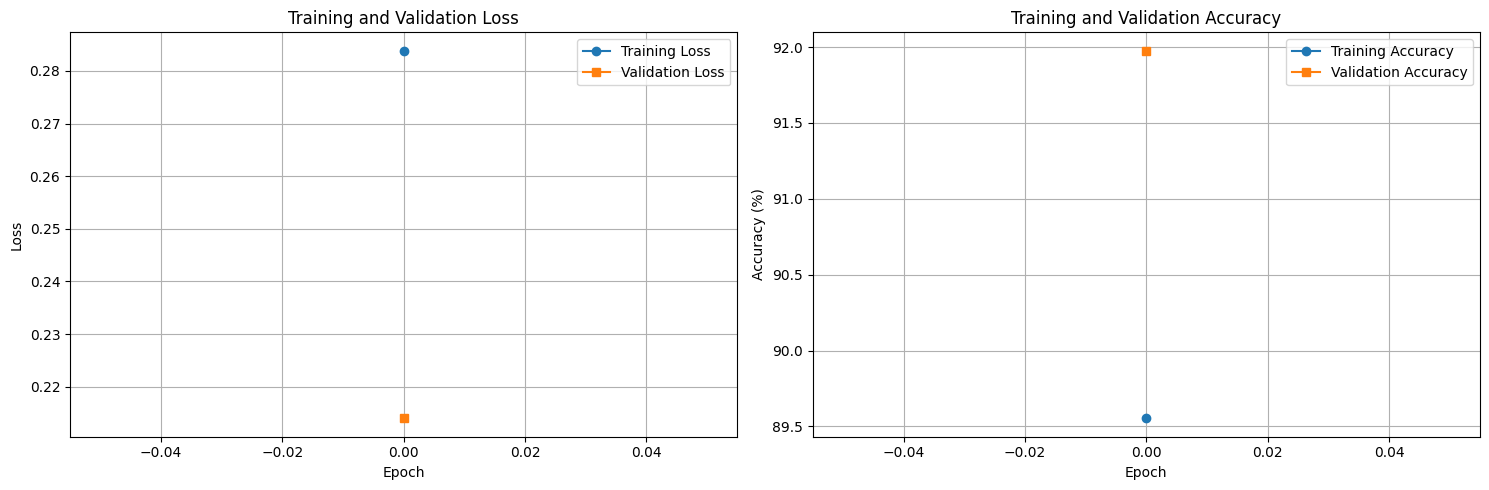


TRAINING COMPLETED SUCCESSFULLY!
Best model: deeplabv3_checkpoints/best_model_epoch_1.pth
Mean IoU: 0.7766
Device used: cuda


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.models.segmentation as models
import torch.nn.functional as F
from torchvision.models import ResNet50_Weights
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class DeepLabV3Segmentation:
    def __init__(self, num_classes, device='cuda', pretrained=True):
        """
        DeepLabV3 with ResNet50 backbone for image segmentation
        
        Args:
            num_classes: Number of segmentation classes (including background)
            device: Device to run on ('cuda' or 'cpu')
            pretrained: Whether to use pretrained weights
        """
        self.device = device
        self.num_classes = num_classes
        
        # Initialize model
        self.model = self._create_model(pretrained)
        # compile model
        # self.model = torch.compile(self.model, mode='max-autotune')
        self.model.to(self.device)
        
        # Training components
        self.optimizer = None
        self.criterion = None
        self.scheduler = None
        
        # Training history
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        
        print(f"DeepLabV3 ResNet50 initialized with {num_classes} classes")
        print(f"Model parameters: {sum(p.numel() for p in self.model.parameters()):,}")
        print(f"Trainable parameters: {sum(p.numel() for p in self.model.parameters() if p.requires_grad):,}")
    
    def _create_model(self, pretrained=True):
        """Create DeepLabV3 model with ResNet50 backbone"""
        if pretrained:
            # Load pretrained model
            model = models.deeplabv3_resnet50(weights='DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1')
            
            # Modify classifier for custom number of classes
            model.classifier[4] = nn.Conv2d(256, self.num_classes, kernel_size=1)
            model.aux_classifier[4] = nn.Conv2d(256, self.num_classes, kernel_size=1)
            
            print("Using pretrained DeepLabV3 ResNet50 weights (COCO+VOC)")
        else:
            # Create model from scratch
            model = models.deeplabv3_resnet50(weights=None, num_classes=self.num_classes)
            print("Created DeepLabV3 ResNet50 from scratch")
        
        return model
    
    def setup_training(self, learning_rate=1e-4, weight_decay=1e-5, class_weights=None):
        """Setup optimizer, loss function, and scheduler"""
        
        # Optimizer
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
        
        # Loss function
        if class_weights is not None:
            # Ensure class weights tensor has correct size
            if len(class_weights) != self.num_classes:
                print(f"Warning: Class weights size ({len(class_weights)}) doesn't match num_classes ({self.num_classes})")
                print("Creating properly sized class weights tensor...")
                
                # Create new tensor with correct size
                new_weights = torch.ones(self.num_classes)
                for i in range(min(len(class_weights), self.num_classes)):
                    new_weights[i] = class_weights[i]
                class_weights = new_weights
            
            class_weights = class_weights.to(self.device)
            print(f"  Class weights shape: {class_weights.shape}")
            print(f"  Class weights values: {class_weights}")
        
        self.criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=255)
        
        # Learning rate scheduler
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=5,
        )
        
        print(f"Training setup complete:")
        print(f"  Learning rate: {learning_rate}")
        print(f"  Weight decay: {weight_decay}")
        print(f"  Class weights: {'Enabled' if class_weights is not None else 'Disabled'}")
        print(f"  Number of classes: {self.num_classes}")
    
    def train_epoch(self, train_loader):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0.0
        correct_pixels = 0
        total_pixels = 0
        
        progress_bar = tqdm(train_loader, desc="Training")
        
        for batch_idx, batch in enumerate(progress_bar):
            images = batch['image'].to(self.device)
            masks = batch['mask'].to(self.device)
            
            # Debug: Check data shapes and values
            if batch_idx == 0:
                print(f"\nDebug - First batch:")
                print(f"  Images shape: {images.shape}")
                print(f"  Masks shape: {masks.shape}")
                print(f"  Unique mask values: {torch.unique(masks)}")
                print(f"  Mask dtype: {masks.dtype}")
            
            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(images)
            
            # Debug: Check output shapes
            if batch_idx == 0:
                print(f"  Output 'out' shape: {outputs['out'].shape}")
                print(f"  Output 'aux' shape: {outputs['aux'].shape}")
            
            # Calculate loss (main output + auxiliary output)
            main_loss = self.criterion(outputs['out'], masks)
            aux_loss = self.criterion(outputs['aux'], masks)
            loss = main_loss + 0.4 * aux_loss  # Standard auxiliary loss weight
            
            # Backward pass
            loss.backward()
            self.optimizer.step()
            
            # Statistics
            total_loss += loss.item()
            predicted = torch.argmax(outputs['out'], dim=1)
            correct_pixels += (predicted == masks).sum().item()
            total_pixels += masks.numel()
            
            # Update progress bar
            avg_loss = total_loss / (batch_idx + 1)
            accuracy = correct_pixels / total_pixels * 100
            progress_bar.set_postfix({
                'Loss': f'{avg_loss:.4f}',
                'Acc': f'{accuracy:.2f}%'
            })
        
        epoch_loss = total_loss / len(train_loader)
        epoch_accuracy = correct_pixels / total_pixels * 100
        
        return epoch_loss, epoch_accuracy
    
    def validate_epoch(self, val_loader):
        """Validate for one epoch"""
        self.model.eval()
        total_loss = 0.0
        correct_pixels = 0
        total_pixels = 0
        
        with torch.no_grad():
            progress_bar = tqdm(val_loader, desc="Validation")
            
            for batch_idx, batch in enumerate(progress_bar):
                images = batch['image'].to(self.device)
                masks = batch['mask'].to(self.device)
                
                # Forward pass
                outputs = self.model(images)
                
                # Calculate loss
                main_loss = self.criterion(outputs['out'], masks)
                aux_loss = self.criterion(outputs['aux'], masks)
                loss = main_loss + 0.4 * aux_loss
                
                # Statistics
                total_loss += loss.item()
                predicted = torch.argmax(outputs['out'], dim=1)
                correct_pixels += (predicted == masks).sum().item()
                total_pixels += masks.numel()
                
                # Update progress bar
                avg_loss = total_loss / (batch_idx + 1)
                accuracy = correct_pixels / total_pixels * 100
                progress_bar.set_postfix({
                    'Loss': f'{avg_loss:.4f}',
                    'Acc': f'{accuracy:.2f}%'
                })
        
        epoch_loss = total_loss / len(val_loader)
        epoch_accuracy = correct_pixels / total_pixels * 100
        
        return epoch_loss, epoch_accuracy
    
    def train(self, train_loader, val_loader, epochs=50, save_dir='checkpoints'):
        """Train the model"""
        os.makedirs(save_dir, exist_ok=True)
        
        best_val_loss = float('inf')
        best_model_path = None
        
        print(f"\nStarting training for {epochs} epochs...")
        print(f"Device: {self.device}")
        print(f"Training samples: {len(train_loader.dataset)}")
        print(f"Validation samples: {len(val_loader.dataset)}")
        print("-" * 60)
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            
            # Training
            train_loss, train_acc = self.train_epoch(train_loader)
            
            # Validation
            val_loss, val_acc = self.validate_epoch(val_loader)
            
            # Learning rate scheduling
            self.scheduler.step(val_loss)
            
            # Save history
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)
            
            # Print epoch summary
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
            print(f"Learning Rate: {self.optimizer.param_groups[0]['lr']:.6f}")
            
            # Save best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_path = os.path.join(save_dir, f'best_model_epoch_{epoch+1}.pth')
                self.save_model(best_model_path, epoch, train_loss, val_loss)
                print(f"✓ New best model saved: {best_model_path}")
            
            # Save checkpoint every 10 epochs
            if (epoch + 1) % 10 == 0:
                checkpoint_path = os.path.join(save_dir, f'checkpoint_epoch_{epoch+1}.pth')
                self.save_model(checkpoint_path, epoch, train_loss, val_loss)
        
        print(f"\nTraining completed!")
        print(f"Best validation loss: {best_val_loss:.4f}")
        print(f"Best model saved at: {best_model_path}")
        
        # Save training history
        self.save_training_history(save_dir)
        
        return best_model_path
    
    def save_model(self, filepath, epoch, train_loss, val_loss):
        """Save model checkpoint"""
        torch.save({
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'num_classes': self.num_classes,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_accuracies': self.train_accuracies,
            'val_accuracies': self.val_accuracies,
        }, filepath)
    
    def load_model(self, filepath):
        """Load model checkpoint"""
        checkpoint = torch.load(filepath, map_location=self.device)
        
        self.model.load_state_dict(checkpoint['model_state_dict'])
        
        if self.optimizer:
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if self.scheduler:
            self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        self.train_losses = checkpoint.get('train_losses', [])
        self.val_losses = checkpoint.get('val_losses', [])
        self.train_accuracies = checkpoint.get('train_accuracies', [])
        self.val_accuracies = checkpoint.get('val_accuracies', [])
        
        print(f"Model loaded from {filepath}")
        print(f"Epoch: {checkpoint['epoch']}")
        print(f"Training loss: {checkpoint['train_loss']:.4f}")
        print(f"Validation loss: {checkpoint['val_loss']:.4f}")
    
    def predict(self, image_tensor):
        """Predict segmentation mask for a single image"""
        self.model.eval()
        
        with torch.no_grad():
            if len(image_tensor.shape) == 3:
                image_tensor = image_tensor.unsqueeze(0)  # Add batch dimension
            
            image_tensor = image_tensor.to(self.device)
            outputs = self.model(image_tensor)
            predictions = torch.argmax(outputs['out'], dim=1)
            
            return predictions.cpu().numpy()
    
    def predict_batch(self, data_loader):
        """Predict segmentation masks for a batch of images"""
        self.model.eval()
        predictions = []
        filenames = []
        
        with torch.no_grad():
            for batch in tqdm(data_loader, desc="Predicting"):
                images = batch['image'].to(self.device)
                outputs = self.model(images)
                batch_predictions = torch.argmax(outputs['out'], dim=1).cpu().numpy()
                
                predictions.extend(batch_predictions)
                filenames.extend(batch['filename'])
        
        return predictions, filenames
    
    def evaluate_iou(self, val_loader):
        """Calculate IoU (Intersection over Union) for each class"""
        self.model.eval()
        
        class_ious = np.zeros(self.num_classes)
        class_counts = np.zeros(self.num_classes)
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Evaluating IoU"):
                images = batch['image'].to(self.device)
                masks = batch['mask'].to(self.device)
                
                outputs = self.model(images)
                predictions = torch.argmax(outputs['out'], dim=1)
                
                # Calculate IoU for each class
                for class_id in range(self.num_classes):
                    pred_mask = (predictions == class_id)
                    true_mask = (masks == class_id)
                    
                    intersection = (pred_mask & true_mask).sum().item()
                    union = (pred_mask | true_mask).sum().item()
                    
                    if union > 0:
                        class_ious[class_id] += intersection / union
                        class_counts[class_id] += 1
        
        # Average IoU per class
        mean_ious = np.divide(class_ious, class_counts, 
                             out=np.zeros_like(class_ious), where=class_counts!=0)
        
        # Overall mean IoU
        mean_iou = np.mean(mean_ious[class_counts > 0])
        
        print("\nIoU Evaluation Results:")
        for i, iou in enumerate(mean_ious):
            if class_counts[i] > 0:
                print(f"Class {i}: {iou:.4f}")
        print(f"Mean IoU: {mean_iou:.4f}")
        
        return mean_ious, mean_iou
    
    def plot_training_history(self, save_path=None):
        """Plot training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss plot
        ax1.plot(self.train_losses, label='Training Loss', marker='o')
        ax1.plot(self.val_losses, label='Validation Loss', marker='s')
        ax1.set_title('Training and Validation Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True)
        
        # Accuracy plot
        ax2.plot(self.train_accuracies, label='Training Accuracy', marker='o')
        ax2.plot(self.val_accuracies, label='Validation Accuracy', marker='s')
        ax2.set_title('Training and Validation Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy (%)')
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Training history plot saved to {save_path}")
        
        plt.show()
    
    def save_training_history(self, save_dir):
        """Save training history to JSON"""
        history = {
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_accuracies': self.train_accuracies,
            'val_accuracies': self.val_accuracies,
            'timestamp': datetime.now().isoformat()
        }
        
        history_path = os.path.join(save_dir, 'training_history.json')
        with open(history_path, 'w') as f:
            json.dump(history, f, indent=2)
        
        print(f"Training history saved to {history_path}")

# Example usage and training script
if __name__ == "__main__":
    # Import your dataset classes (assuming they're in the same file or imported)
    # from dataset import create_data_loaders_with_split, analyze_dataset, calculate_class_weights
    
    # Configuration
    CONFIG = {
        'image_dir': "/home/eyhyd/signature_comparison_project/signver/datasets/cropped_images",
        'mask_dir': "/home/eyhyd/signature_comparison_project/signver/datasets/cropped_masks",
        'num_classes': 2,  # Adjust based on your dataset (background + signature)
        'batch_size': 8,  # Adjust based on your GPU memory
        'image_size': (512, 512),
        'learning_rate': 1e-4,
        'epochs': 1,
        'val_split': 0.25,
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'signature_mode': True  # Enable for signature dataset
    }
    
    print("="*60)
    print("DeepLabV3 ResNet50 Segmentation Training")
    print("="*60)
    
    # 1. Create data loaders
    print("1. Loading dataset...")
    train_loader, val_loader, train_dataset, val_dataset = create_data_loaders_with_split(
        CONFIG['image_dir'], CONFIG['mask_dir'],
        val_split=CONFIG['val_split'],
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        signature_mode=CONFIG['signature_mode']
    )
    
    # 2. Analyze dataset and calculate class weights
    print("\n2. Analyzing dataset...")
    class_counts = analyze_dataset(train_dataset)
    class_weights = calculate_class_weights(class_counts)
    
    # Debug: Check class information
    print(f"\nDebug Info:")
    print(f"  Classes found in dataset: {sorted(class_counts.keys())}")
    print(f"  Number of classes in CONFIG: {CONFIG['num_classes']}")
    print(f"  Class weights tensor size: {len(class_weights)}")
    
    # Ensure class weights match expected number of classes
    if len(class_weights) != CONFIG['num_classes']:
        print(f"  Adjusting class weights to match CONFIG['num_classes']...")
        new_weights = torch.ones(CONFIG['num_classes'])
        for i in range(min(len(class_weights), CONFIG['num_classes'])):
            new_weights[i] = class_weights[i]
        class_weights = new_weights
        print(f"  Adjusted class weights: {class_weights}")
    
    # 3. Initialize model
    print(f"\n3. Initializing DeepLabV3 model...")
    model = DeepLabV3Segmentation(
        num_classes=CONFIG['num_classes'],
        device=CONFIG['device'],
        pretrained=True
    )
    
    # 4. Setup training
    print("\n4. Setting up training...")
    model.setup_training(
        learning_rate=CONFIG['learning_rate'],
        class_weights=class_weights
    )
    
    # 5. Train model
    print("\n5. Starting training...")
    best_model_path = model.train(
        train_loader, val_loader,
        epochs=CONFIG['epochs'],
        save_dir='deeplabv3_checkpoints'
    )
    
    # 6. Evaluate model
    print("\n6. Evaluating model...")
    mean_ious, mean_iou = model.evaluate_iou(val_loader)
    
    # 7. Plot training history
    print("\n7. Plotting training history...")
    model.plot_training_history('training_history.png')
    
    print("\n" + "="*60)
    print("TRAINING COMPLETED SUCCESSFULLY!")
    print("="*60)
    print(f"Best model: {best_model_path}")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Device used: {CONFIG['device']}")
    print("="*60)

SINGLE IMAGE PREDICTION
🚀 Starting prediction...
Loading checkpoint from: deeplabv3_checkpoints/best_model_epoch_1.pth
✓ Model loaded successfully
✓ Device: cuda
✓ Classes: 2
✓ Epoch: 0
✓ Validation loss: 0.2140
✓ Visualization saved to: prediction_result_original_size.png


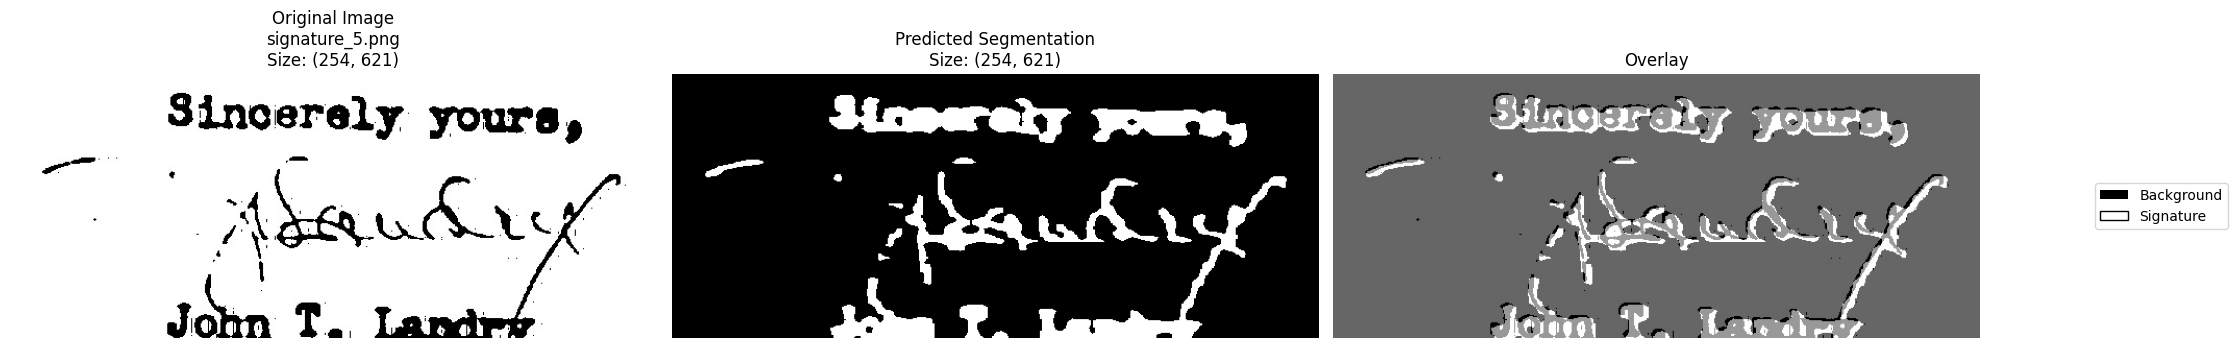


📊 Prediction Statistics:
Original image size: (254, 621)
Prediction size: (254, 621)
Unique prediction values: [0 1]
Background: 136,765 pixels (86.7%)
Signature: 20,969 pixels (13.3%)
✅ Prediction completed!


In [11]:
import torch
import torch.nn as nn
import torchvision.models.segmentation as models
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

class SignaturePredictor:
    def __init__(self, model_path, device='cuda'):
        """
        Simple predictor for signature segmentation
        
        Args:
            model_path: Path to the trained model checkpoint
            device: Device to run on ('cuda' or 'cpu')
        """
        self.device = device if torch.cuda.is_available() else 'cpu'
        
        # Load checkpoint to get model info
        print(f"Loading checkpoint from: {model_path}")
        checkpoint = torch.load(model_path, map_location=self.device)
        self.num_classes = checkpoint.get('num_classes', 2)
        
        # Create model (exactly as in training)
        self.model = self._create_model()
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.to(self.device)
        self.model.eval()
        
        # Preprocessing pipeline (EXACTLY as in training)
        self.transform = A.Compose([
            A.Resize(512, 512),
            A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # 3-channel normalization
            ToTensorV2(),
        ])
        
        print(f"✓ Model loaded successfully")
        print(f"✓ Device: {self.device}")
        print(f"✓ Classes: {self.num_classes}")
        print(f"✓ Epoch: {checkpoint.get('epoch', 'Unknown')}")
        print(f"✓ Validation loss: {checkpoint.get('val_loss', 'Unknown'):.4f}")
    
    def _create_model(self):
        """Create model architecture (exactly as in training)"""
        # Load pretrained DeepLabV3
        model = models.deeplabv3_resnet50(weights='DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1')
        
        # Modify for custom classes
        model.classifier[4] = nn.Conv2d(256, self.num_classes, kernel_size=1)
        model.aux_classifier[4] = nn.Conv2d(256, self.num_classes, kernel_size=1)
        
        return model
    
    def predict_image(self, image_path, return_original_size=True):
        """
        Predict segmentation mask for a single image
        
        Args:
            image_path: Path to input image
            return_original_size: If True, resize prediction back to original image size
            
        Returns:
            original_image: Original grayscale image
            prediction: Predicted segmentation mask
        """
        image_path = Path(image_path)
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")
        
        # Load image as color (as in training dataset)
        original_bgr = cv2.imread(str(image_path))
        if original_bgr is None:
            raise ValueError(f"Could not load image: {image_path}")
        
        # Store original dimensions
        original_height, original_width = original_bgr.shape[:2]
        
        # Convert BGR to RGB (as in training dataset)
        image_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
        
        # For display purposes, convert to grayscale
        original_gray = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2GRAY)
        
        # Apply same preprocessing as training (resizes to 512x512)
        transformed = self.transform(image=image_rgb)
        image_tensor = transformed['image'].unsqueeze(0).to(self.device)
        
        # Predict
        with torch.no_grad():
            outputs = self.model(image_tensor)
            prediction = torch.argmax(outputs['out'], dim=1).cpu().numpy()[0]
        
        # Resize prediction back to original size if requested
        if return_original_size:
            prediction = cv2.resize(
                prediction.astype(np.uint8), 
                (original_width, original_height), 
                interpolation=cv2.INTER_NEAREST  # Use nearest neighbor to preserve class labels
            )
        
        return original_gray, prediction
    
    def visualize_prediction(self, image_path, save_path=None, show_plot=True, original_size=True):
        """
        Predict and visualize segmentation
        
        Args:
            image_path: Path to input image
            save_path: Path to save visualization (optional)
            show_plot: Whether to display the plot
            original_size: If True, show results in original image size
        """
        # Get prediction
        original_image, prediction = self.predict_image(image_path, return_original_size=original_size)
        
        # Create binary colored mask (black background, white signature)
        colored_mask = np.zeros((*prediction.shape, 3))
        colored_mask[prediction == 0] = [0, 0, 0]  # Background = black
        colored_mask[prediction == 1] = [1, 1, 1]  # Signature = white (new fixed model)
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(20, 8))  # Increased figure size for original dimensions
        
        # Original image
        axes[0].imshow(original_image, cmap='gray')
        axes[0].set_title(f'Original Image\n{Path(image_path).name}\nSize: {original_image.shape}')
        axes[0].axis('off')
        
        # Prediction mask
        axes[1].imshow(colored_mask)
        axes[1].set_title(f'Predicted Segmentation\nSize: {prediction.shape}')
        axes[1].axis('off')
        
        # Overlay
        axes[2].imshow(original_image, cmap='gray')
        axes[2].imshow(colored_mask, alpha=0.6)
        axes[2].set_title('Overlay')
        axes[2].axis('off')
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='black', label='Background'),
            Patch(facecolor='white', label='Signature', edgecolor='black')
        ]
        fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.12, 0.5))
        
        plt.tight_layout()
        
        # Save if requested
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✓ Visualization saved to: {save_path}")
        
        # Show plot
        if show_plot:
            plt.show()
        else:
            plt.close()
        
        # Print statistics
        unique_classes, counts = np.unique(prediction, return_counts=True)
        total_pixels = prediction.size
        
        print(f"\n📊 Prediction Statistics:")
        print(f"Original image size: {original_image.shape}")
        print(f"Prediction size: {prediction.shape}")
        print(f"Unique prediction values: {unique_classes}")
        for class_id, count in zip(unique_classes, counts):
            percentage = count / total_pixels * 100
            class_name = "Background" if class_id == 0 else "Signature"
            print(f"{class_name}: {count:,} pixels ({percentage:.1f}%)")
        
        return original_image, prediction
    
    def predict_batch(self, input_dir, output_dir):
        """
        Predict multiple images in a directory
        
        Args:
            input_dir: Directory containing input images
            output_dir: Directory to save results
        """
        input_dir = Path(input_dir)
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Find all image files
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
        image_files = []
        for ext in image_extensions:
            image_files.extend(list(input_dir.glob(f'*{ext}')))
            image_files.extend(list(input_dir.glob(f'*{ext.upper()}')))
        
        print(f"Found {len(image_files)} images to process")
        
        # Process each image
        for i, image_path in enumerate(image_files, 1):
            print(f"\nProcessing {i}/{len(image_files)}: {image_path.name}")
            
            try:
                output_path = output_dir / f"{image_path.stem}_segmentation.png"
                self.visualize_prediction(
                    image_path, 
                    save_path=output_path,
                    show_plot=False  # Don't show plots for batch processing
                )
            except Exception as e:
                print(f"❌ Error processing {image_path}: {e}")
        
        print(f"\n✅ Batch processing completed! Results saved to {output_dir}")

def predict_single_image(model_path, image_path, output_path=None, original_size=True):
    """
    Convenience function to predict a single image
    
    Args:
        model_path: Path to trained model checkpoint
        image_path: Path to input image
        output_path: Path to save result (optional)
        original_size: If True, return results in original image size
    """
    print("🚀 Starting prediction...")
    
    # Initialize predictor
    predictor = SignaturePredictor(model_path)
    
    # Predict and visualize
    original, prediction = predictor.visualize_prediction(
        image_path, 
        save_path=output_path,
        show_plot=True,
        original_size=original_size
    )
    
    print("✅ Prediction completed!")
    return original, prediction

def predict_batch_images(model_path, input_dir, output_dir):
    """
    Convenience function to predict multiple images
    
    Args:
        model_path: Path to trained model
        input_dir: Directory containing input images
        output_dir: Directory to save results
    """
    print("🚀 Starting batch prediction...")
    
    # Initialize predictor
    predictor = SignaturePredictor(model_path)
    
    # Process batch
    predictor.predict_batch(input_dir, output_dir)
    
    print("✅ Batch prediction completed!")

# Example usage
if __name__ == "__main__":
    # Configuration
    MODEL_PATH = "deeplabv3_checkpoints/best_model_epoch_1.pth"  # Update this path
    
    # Example 1: Predict single image
    print("=" * 60)
    print("SINGLE IMAGE PREDICTION")
    print("=" * 60)
    
    predict_single_image(
        model_path=MODEL_PATH,
        image_path="/home/eyhyd/signature_comparison_project/signver/datasets/cropped_images/signature_5.png",
        output_path="prediction_result_original_size.png",
        original_size=True  # This will show results in original image dimensions
    )
    
    # Example 2: Batch prediction (uncomment to use)
    # print("\n" + "=" * 60)
    # print("BATCH PREDICTION")
    # print("=" * 60)
    # 
    # predict_batch_images(
    #     model_path=MODEL_PATH,
    #     input_dir="test_images/",
    #     output_dir="prediction_results/"
    # )
    
    # Example 3: Using predictor object directly for custom workflow
    # print("\n" + "=" * 60)
    # print("CUSTOM PREDICTION WORKFLOW")
    # print("=" * 60)
    # 
    # predictor = SignaturePredictor(MODEL_PATH)
    # 
    # # Predict multiple images with custom processing
    # test_images = [
    #     "signature_1.png",
    #     "signature_2.png", 
    #     "signature_3.png"
    # ]
    # 
    # for img_path in test_images:
    #     try:
    #         original, prediction = predictor.predict_image(img_path)
    #         print(f"Processed {img_path}: {np.sum(prediction == 1)} signature pixels")
    #     except Exception as e:
    #         print(f"Error with {img_path}: {e}")

SINGLE IMAGE PREDICTION
🚀 Starting prediction...
Loading checkpoint from: deeplabv3_checkpoints/best_model_epoch_1_bkp.pth
✓ Model loaded successfully
✓ Device: cuda
✓ Classes: 2
✓ Epoch: 0
✓ Validation loss: 0.1723
✓ Visualization saved to: prediction_result_original_size.png


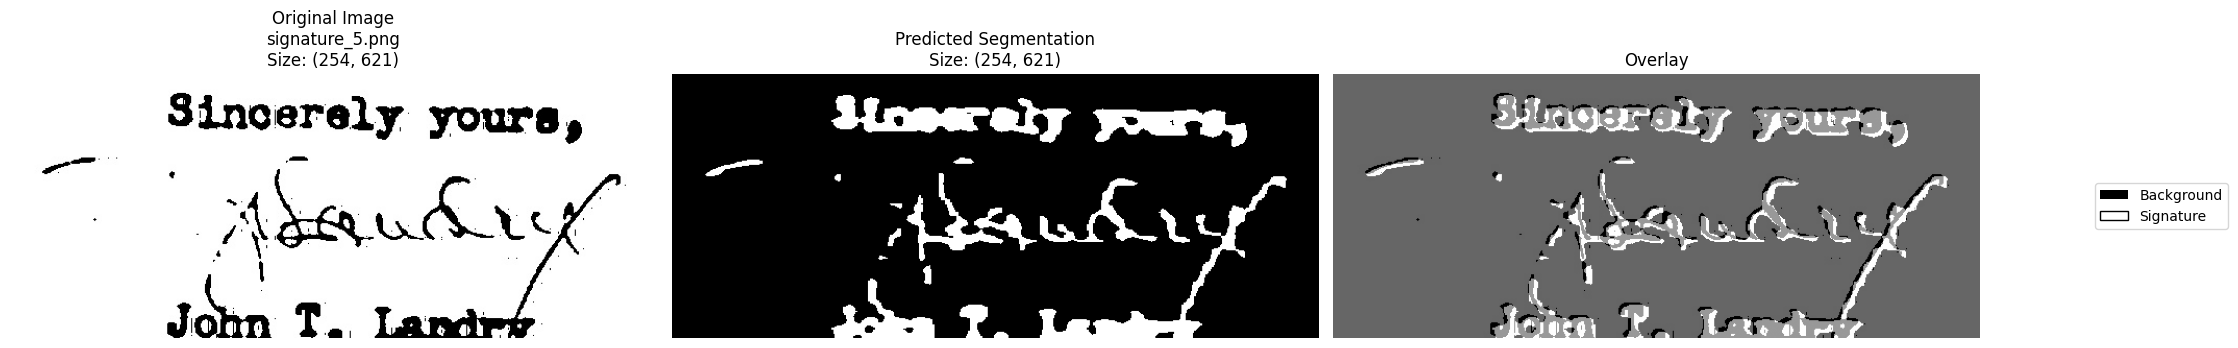


📊 Prediction Statistics:
Original image size: (254, 621)
Prediction size: (254, 621)
Unique prediction values: [0 1]
Background: 139,177 pixels (88.2%)
Signature: 18,557 pixels (11.8%)
✅ Prediction completed!


(array([[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]], shape=(254, 621), dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(254, 621), dtype=uint8))

In [12]:
# Configuration
MODEL_PATH = "deeplabv3_checkpoints/best_model_epoch_1_bkp.pth"  # Update this path

# Example 1: Predict single image
print("=" * 60)
print("SINGLE IMAGE PREDICTION")
print("=" * 60)

predict_single_image(
    model_path=MODEL_PATH,
    image_path="/home/eyhyd/signature_comparison_project/signver/datasets/cropped_images/signature_5.png",
    output_path="prediction_result_original_size.png",
    original_size=True  # This will show results in original image dimensions
)

SINGLE IMAGE PREDICTION
🚀 Starting prediction...
Loading checkpoint from: deeplabv3_checkpoints/best_model_epoch_1.pth
✓ Model loaded successfully
✓ Device: cuda
✓ Classes: 2
✓ Epoch: 0
✓ Validation loss: 0.2140
✓ Visualization saved to: prediction_result_original_size.png


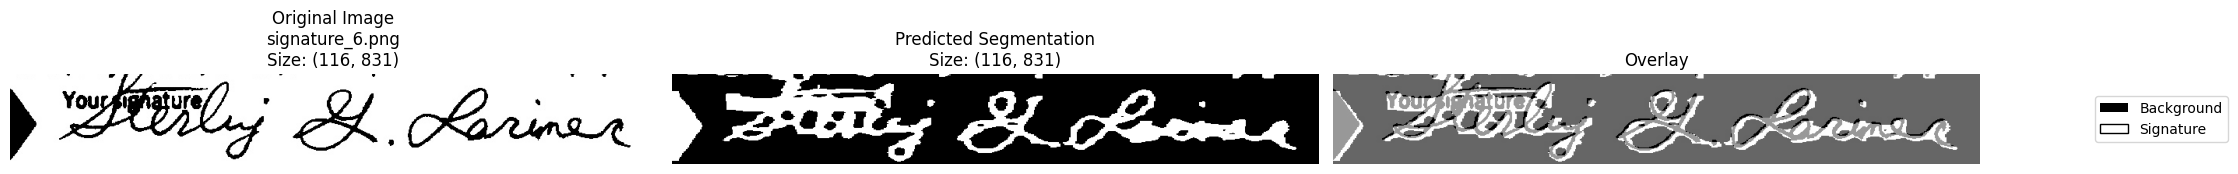


📊 Prediction Statistics:
Original image size: (116, 831)
Prediction size: (116, 831)
Unique prediction values: [0 1]
Background: 73,817 pixels (76.6%)
Signature: 22,579 pixels (23.4%)
✅ Prediction completed!


(array([[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]], shape=(116, 831), dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(116, 831), dtype=uint8))

In [13]:
# Configuration
MODEL_PATH = "deeplabv3_checkpoints/best_model_epoch_1.pth"  # Update this path

# Example 1: Predict single image
print("=" * 60)
print("SINGLE IMAGE PREDICTION")
print("=" * 60)

predict_single_image(
    model_path=MODEL_PATH,
    image_path="/home/eyhyd/signature_comparison_project/signver/datasets/cropped_images/signature_6.png",
    output_path="prediction_result_original_size.png",
    original_size=True  # This will show results in original image dimensions
)

SINGLE IMAGE PREDICTION
🚀 Starting prediction...
Loading checkpoint from: deeplabv3_checkpoints/best_model_epoch_1.pth
✓ Model loaded successfully
✓ Device: cuda
✓ Classes: 2
✓ Epoch: 0
✓ Validation loss: 0.2140
✓ Visualization saved to: prediction_result_original_size.png


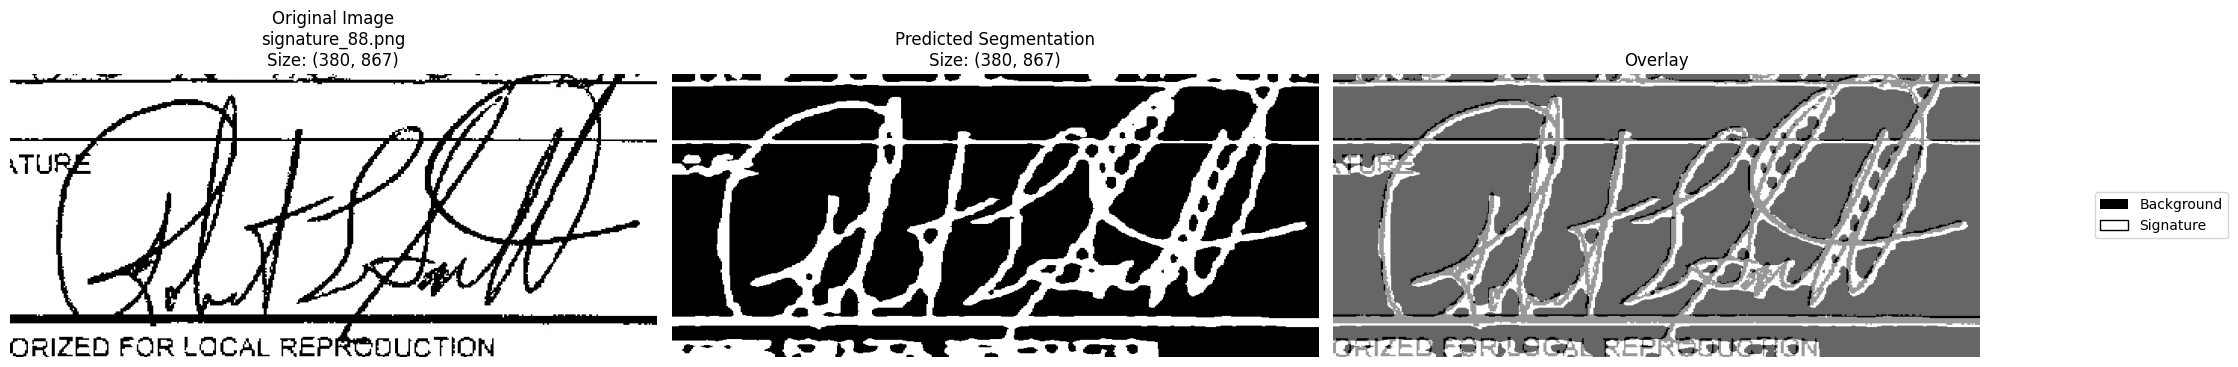


📊 Prediction Statistics:
Original image size: (380, 867)
Prediction size: (380, 867)
Unique prediction values: [0 1]
Background: 235,314 pixels (71.4%)
Signature: 94,146 pixels (28.6%)
✅ Prediction completed!


(array([[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [254, 255, 255, ..., 255, 255, 255],
        [254, 255, 255, ..., 255, 255, 255],
        [255, 254, 255, ..., 255, 255, 255]], shape=(380, 867), dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], shape=(380, 867), dtype=uint8))

In [14]:
# Configuration
MODEL_PATH = "deeplabv3_checkpoints/best_model_epoch_1.pth"  # Update this path

# Example 1: Predict single image
print("=" * 60)
print("SINGLE IMAGE PREDICTION")
print("=" * 60)

predict_single_image(
    model_path=MODEL_PATH,
    image_path="/home/eyhyd/signature_comparison_project/signver/datasets/cropped_images/signature_88.png",
    output_path="prediction_result_original_size.png",
    original_size=True  # This will show results in original image dimensions
)

# Refined Dataset

=== Using single directory with signature-optimized augmentations ===
Found 5623 valid image-mask pairs
Total samples: 5623
Train samples: 4499
Validation samples: 1124
Validation split: 20.0%
Using signature-optimized augmentations
Created subset with 4499 samples from indices
Created subset with 1124 samples from indices
Training samples: 4499
Validation samples: 1124
Analyzing dataset...

Dataset Analysis:
Total pixels analyzed: 26,214,400
Classes found: [0, 1]
Class 0: 22,914,247 pixels (87.41%)
Class 1: 3,300,153 pixels (12.59%)

Class weights (inverse_freq):
Class 0: 0.5720
Class 1: 3.9717
Split info saved to ./split_info/

Testing data loading...
=== Training Loader ===
Batch 0:
  Images shape: torch.Size([8, 3, 512, 512])
  Masks shape: torch.Size([8, 512, 512])
  Unique classes in batch: tensor([0, 1])
  Sample filenames: ['signature_6224.png', 'signature_6058.png', 'signature_3085.png']
Batch 1:
  Images shape: torch.Size([8, 3, 512, 512])
  Masks shape: torch.Size([8, 512, 5

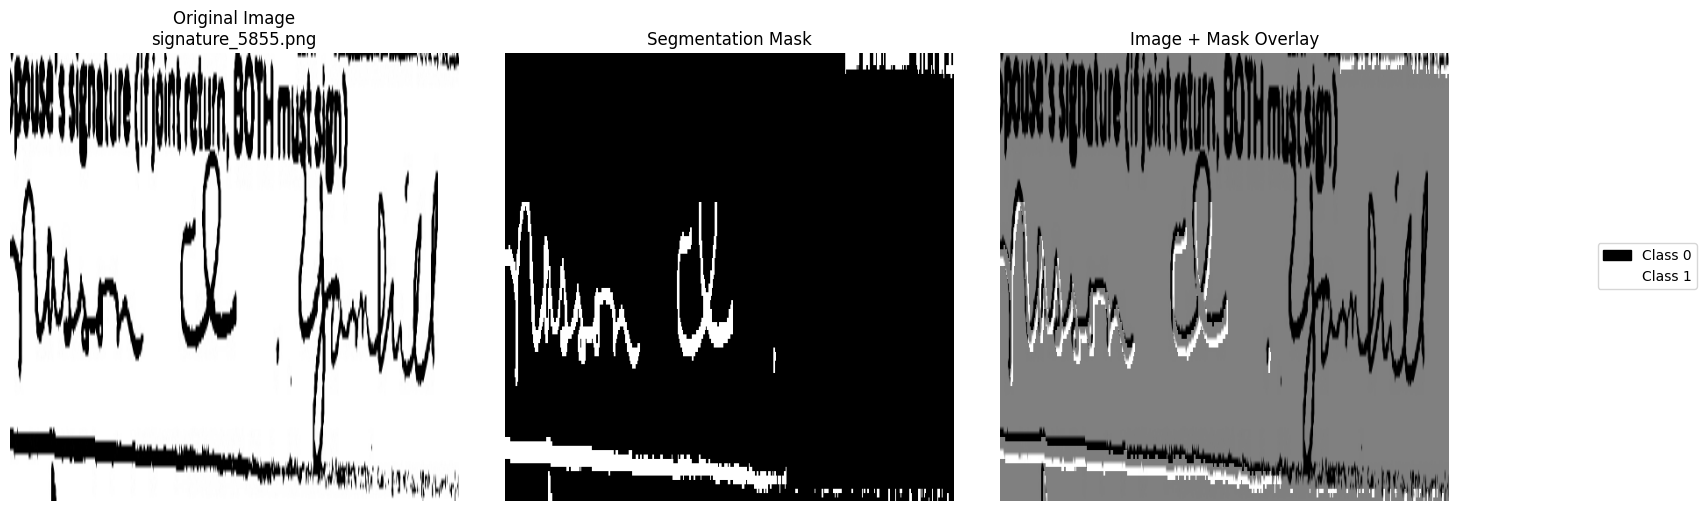


Sample Info:
Filename: signature_5855.png
Image shape: (512, 512, 3)
Mask shape: (512, 512)
Unique classes: [0 1]
Class distribution: [(0, 244131), (1, 18013)]

2. Visualizing random samples from training set...
Random samples visualization saved to random_samples.png


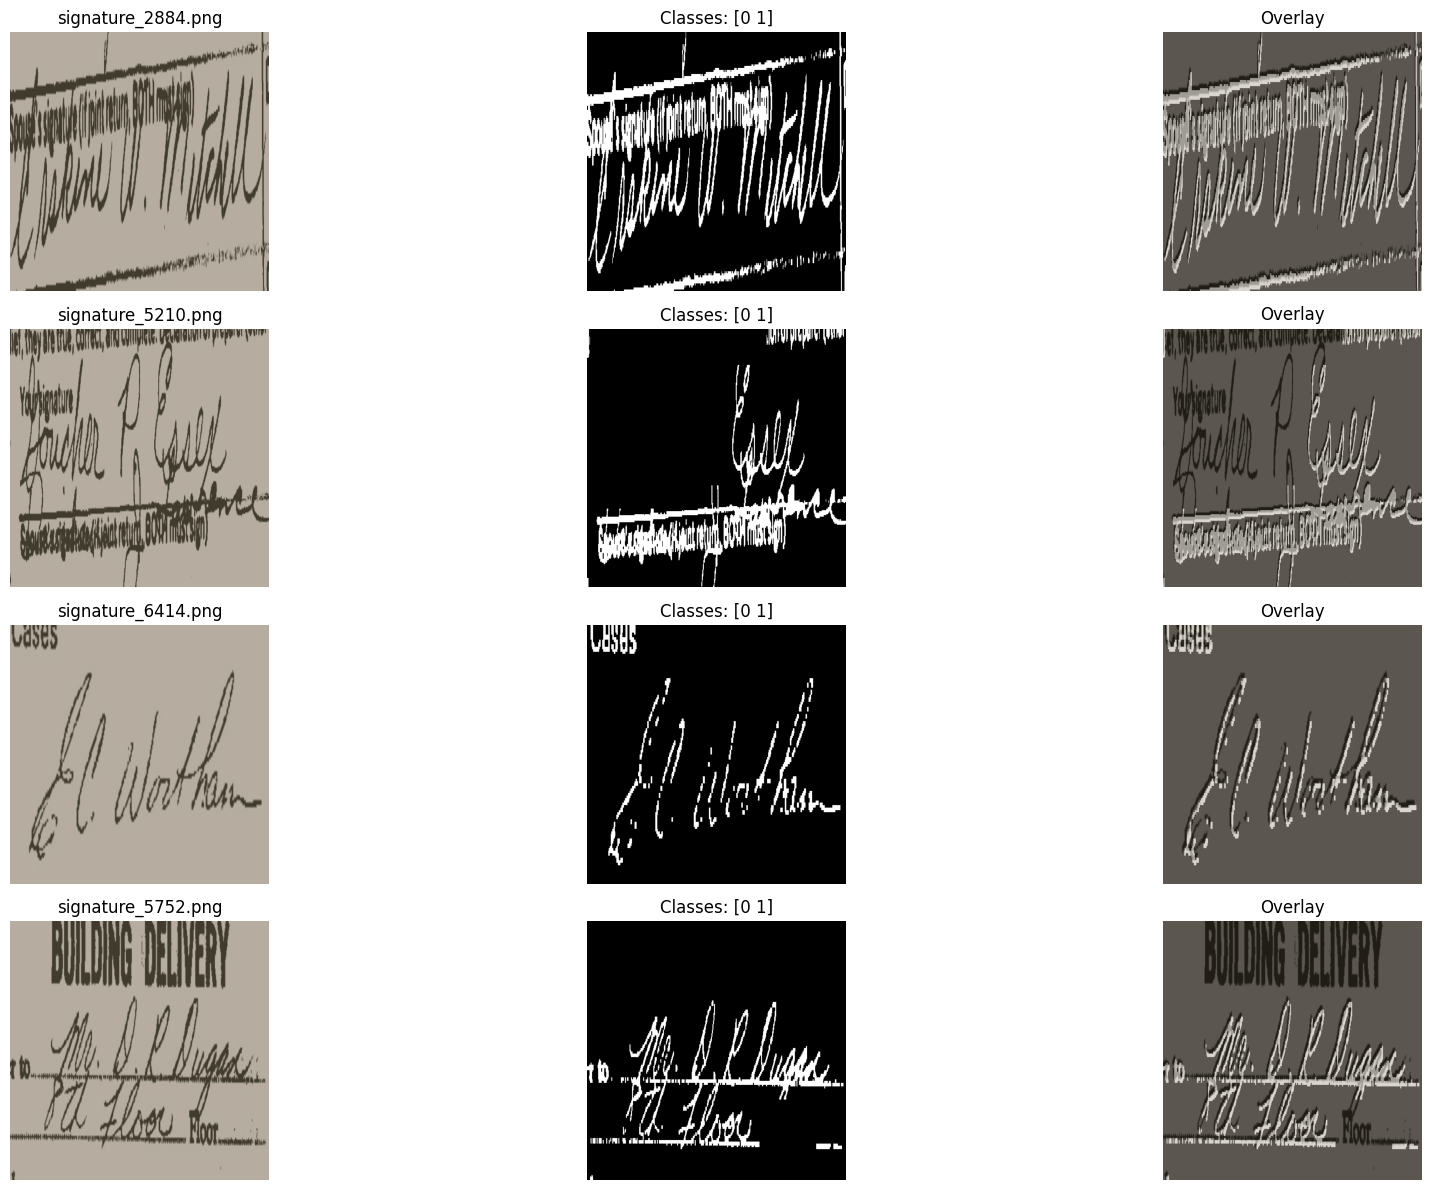


3. Visualizing batch from training loader...
Batch visualization saved to batch_visualization.png


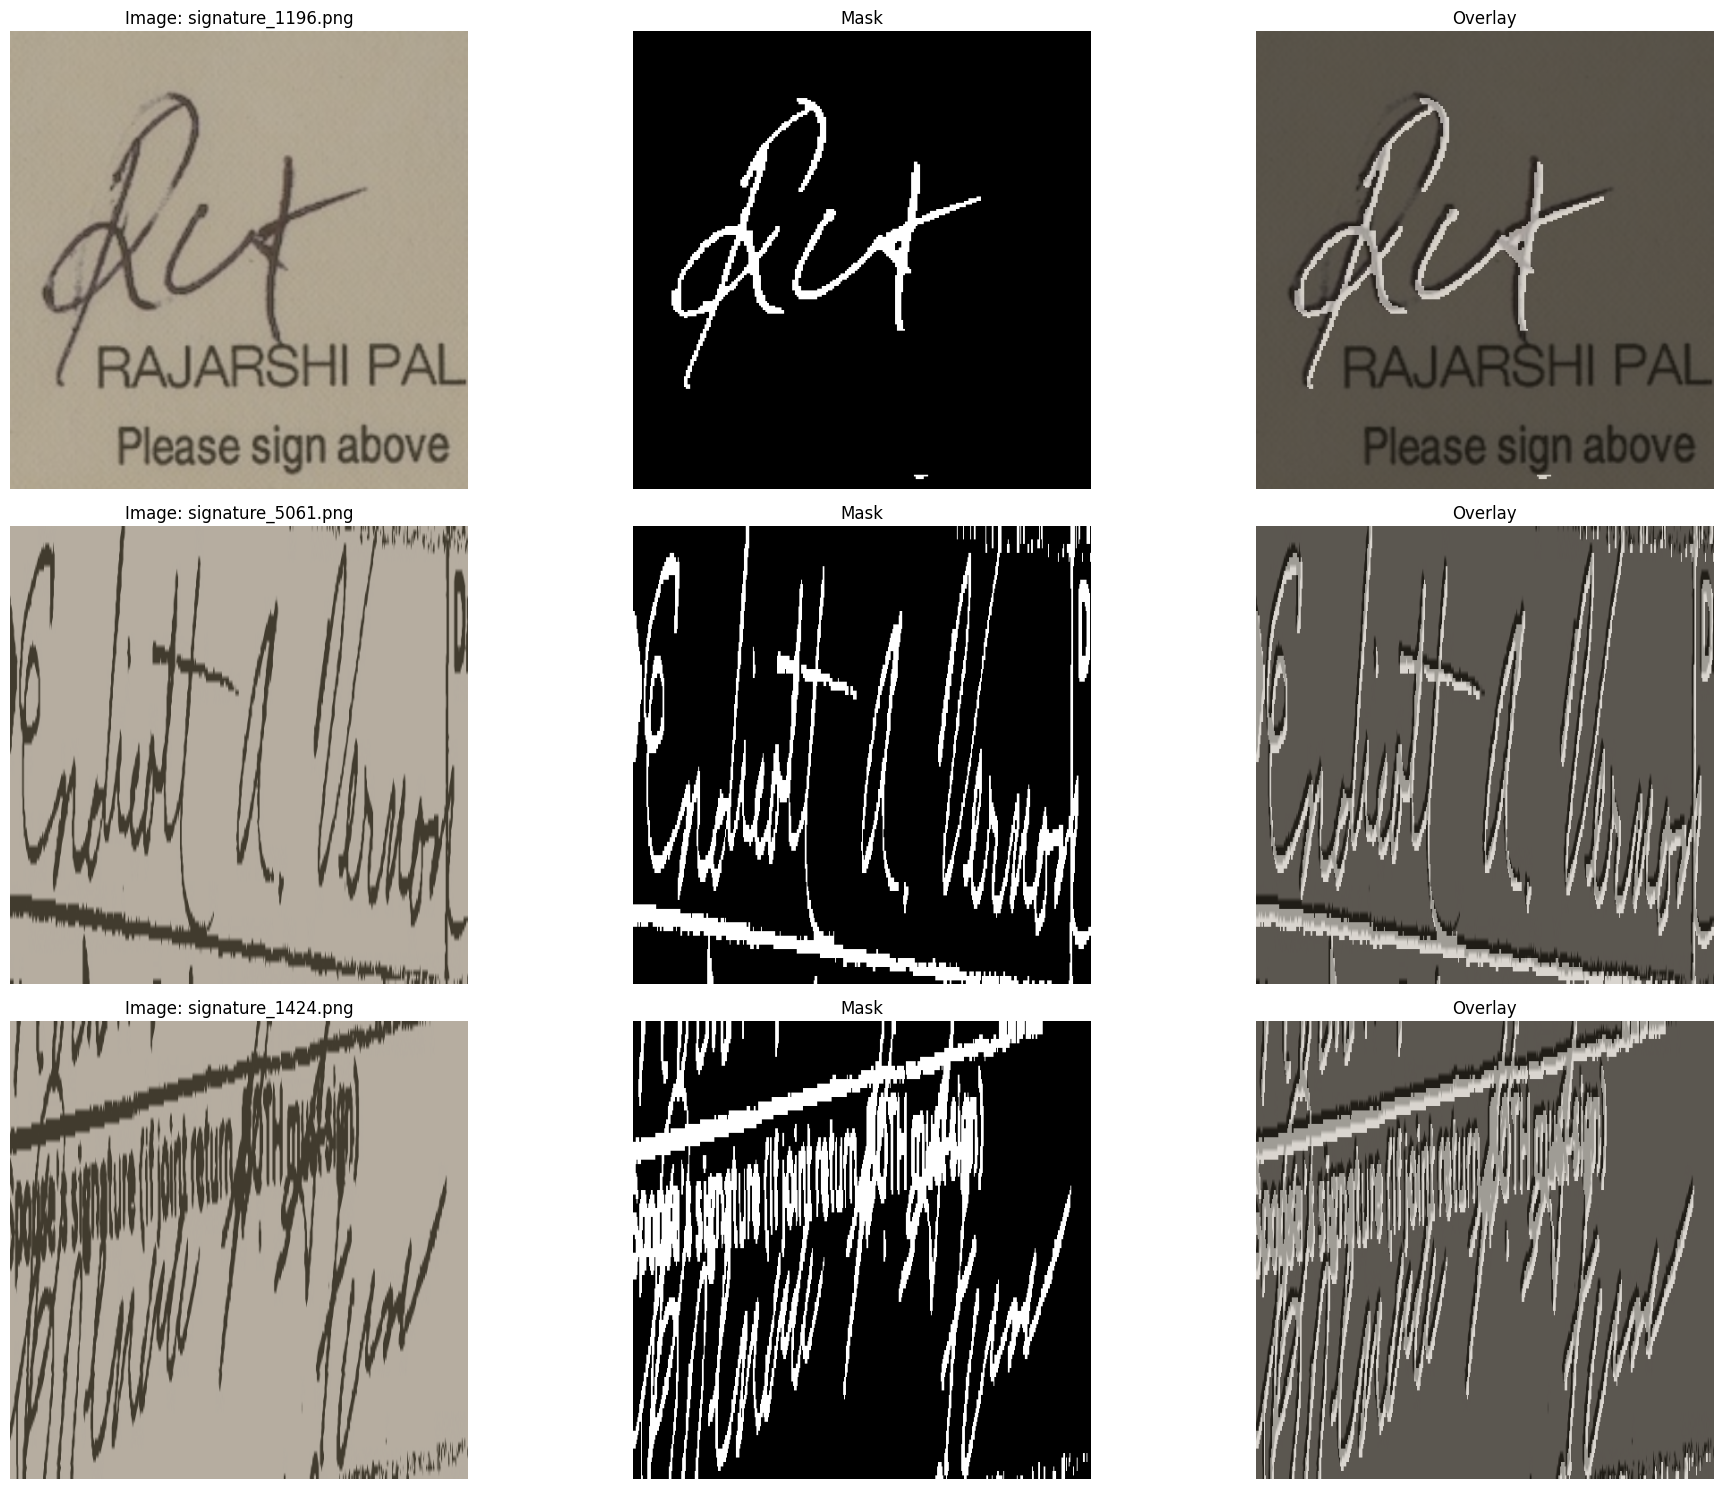

In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from pathlib import Path
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import random

class SegmentationDatasetWithIndices(Dataset):
    def __init__(self, image_dir, mask_dir, indices, transform=None, image_size=(512, 512)):
        """
        Dataset for image segmentation with specific indices (for train/val split)
        
        Args:
            image_dir: Directory containing input images
            mask_dir: Directory containing segmentation masks
            indices: List of indices to use from the full dataset
            transform: Albumentations transform pipeline
            image_size: Target size for images (height, width)
        """
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.image_size = image_size
        
        # Get all image files
        all_image_files = sorted([f for f in os.listdir(image_dir) 
                                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp'))])
        
        # Verify masks exist and create valid pairs
        all_valid_pairs = []
        for img_file in all_image_files:
            mask_file = self._get_mask_filename(img_file)
            if (self.mask_dir / mask_file).exists():
                all_valid_pairs.append((img_file, mask_file))
        
        # Filter by indices
        self.valid_pairs = [all_valid_pairs[i] for i in indices if i < len(all_valid_pairs)]
        
        print(f"Created subset with {len(self.valid_pairs)} samples from indices")
    
    def _get_mask_filename(self, image_filename):
        """Convert image filename to mask filename (adjust as needed)"""
        name, ext = os.path.splitext(image_filename)
        # Common mask naming conventions
        possible_masks = [
            f"{name}_mask{ext}",
            f"{name}_gt{ext}",
            f"{name}.png",  # masks often saved as PNG
            f"{name}_seg.png",
            f"cleaned_{name}.png",  # Example for cleaned masks
        ]
        
        for mask_name in possible_masks:
            if (self.mask_dir / mask_name).exists():
                return mask_name
        
        return f"{name}.png"  # default fallback
    
    def __len__(self):
        return len(self.valid_pairs)
    
    def __getitem__(self, idx):
        img_file, mask_file = self.valid_pairs[idx]
        
        # Load image
        image_path = self.image_dir / img_file
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask_path = self.mask_dir / mask_file
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        mask = (mask > 127).astype(np.uint8)
        
        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # Convert mask to long tensor for CrossEntropyLoss
        mask = mask.long()
        
        return {
            'image': image,
            'mask': mask,
            'filename': img_file
        }

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, image_size=(512, 512)):
        """
        Dataset for image segmentation
        
        Args:
            image_dir: Directory containing input images
            mask_dir: Directory containing segmentation masks
            transform: Albumentations transform pipeline
            image_size: Target size for images (height, width)
        """
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.image_size = image_size
        
        # Get all image files
        self.image_files = sorted([f for f in os.listdir(image_dir) 
                                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp'))])
        
        # Verify masks exist
        self.valid_pairs = []
        for img_file in self.image_files:
            mask_file = self._get_mask_filename(img_file)
            if (self.mask_dir / mask_file).exists():
                self.valid_pairs.append((img_file, mask_file))
        
        print(f"Found {len(self.valid_pairs)} valid image-mask pairs")
    
    def _get_mask_filename(self, image_filename):
        """Convert image filename to mask filename (adjust as needed)"""
        name, ext = os.path.splitext(image_filename)
        
        # print(f"Looking for mask for: {name} {ext}")
        # Common mask naming conventions
        possible_masks = [
            f"{name}_mask{ext}",
            f"{name}_gt{ext}",
            f"{name}.png",  # masks often saved as PNG
            f"{name}_seg.png",
            f"cleaned_{name}.png",
        ]
        
        for mask_name in possible_masks:
            if (self.mask_dir / mask_name).exists():
                return mask_name
        
        return f"{name}.png"  # default fallback
    
    def __len__(self):
        return len(self.valid_pairs)
    
    def __getitem__(self, idx):
        img_file, mask_file = self.valid_pairs[idx]
        
        # Load image
        image_path = self.image_dir / img_file
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask_path = self.mask_dir / mask_file
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        mask = (mask > 127).astype(np.uint8)  # Convert to binary mask (0 or 1)
        
        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # Convert mask to long tensor for CrossEntropyLoss
        mask = mask.long()
        
        return {
            'image': image,
            'mask': mask,
            'filename': img_file
        }

def get_transforms(image_size=(512, 512), augment=True, signature_mode=False):
    """Get transform pipelines for training and validation
    
    Args:
        image_size: Target image size (height, width)
        augment: Whether to apply augmentations
        signature_mode: If True, applies signature-specific augmentations for black/white images
    """
    
    if signature_mode:
        # Signature-specific normalization (grayscale)
        normalize = A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])    # For grayscale
        
        if augment:
            # Signature-optimized training transforms
            train_transform = A.Compose([
                A.Resize(image_size[0], image_size[1]),
                
                # Geometric augmentations (preserve signature structure)
                # A.OneOf([
                #     A.Rotate(limit=15, p=1),  # Small rotations only
                #     A.Affine(scale=(0.9, 1.1), translate_percent=0.1, rotate=(-10, 10), 
                #             shear=(-5, 5), p=1),  # Slight perspective changes
                # ], p=0.7),
                
                # # Elastic deformation (simulate pen pressure variations)
                # A.ElasticTransform(alpha=50, sigma=5, alpha_affine=5, p=0.3),
                
                # # # Signature thickness variations
                # # A.OneOf([
                # #     A.Dilate(kernel_size=3, iterations=1, p=1),  # Thicker strokes
                # #     A.Erode(kernel_size=3, iterations=1, p=1),   # Thinner strokes
                # # ], p=0.4),
                
                # # Intensity variations (simulate different pen/paper)
                # A.OneOf([
                #     A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1),
                #     A.RandomGamma(gamma_limit=(80, 120), p=1),
                #     A.CLAHE(clip_limit=3, p=1),
                # ], p=0.5),
                
                # # Noise (simulate scanning artifacts)
                # A.OneOf([
                #     A.GaussNoise(var_limit=(5, 25), p=1),
                #     A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1),
                #     A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1),
                # ], p=0.3),
                
                # # Slight blur (simulate pen bleeding)
                # A.OneOf([
                #     A.GaussianBlur(blur_limit=(1, 3), p=1),
                #     A.MotionBlur(blur_limit=3, p=1),
                # ], p=0.2),
                
                # # Grid distortion (simulate paper warping)
                # A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.2),
                
                normalize,
                ToTensorV2(),
            ])
        else:
            # Minimal augmentation for signature training
            train_transform = A.Compose([
                A.Resize(image_size[0], image_size[1]),
                A.Rotate(limit=5, p=0.3),  # Very slight rotation
                A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
                normalize,
                ToTensorV2(),
            ])
        
        # Validation transforms (no augmentation)
        val_transform = A.Compose([
            A.Resize(image_size[0], image_size[1]),
            normalize,
            ToTensorV2(),
        ])
        
    else:
        # Standard RGB augmentations (original code)
        if augment:
            train_transform = A.Compose([
                A.Resize(image_size[0], image_size[1]),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.2),
                A.RandomRotate90(p=0.5),
                A.OneOf([
                    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1),
                    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=1),
                    A.CLAHE(clip_limit=2, p=1),
                ], p=0.5),
                A.OneOf([
                    A.GaussianBlur(blur_limit=3, p=1),
                    A.MotionBlur(blur_limit=3, p=1),
                ], p=0.2),
                A.GaussNoise(var_limit=(10, 50), p=0.2),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ])
        else:
            train_transform = A.Compose([
                A.Resize(image_size[0], image_size[1]),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ])
        
        val_transform = A.Compose([
            A.Resize(image_size[0], image_size[1]),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    
    return train_transform, val_transform

def analyze_dataset(dataset):
    """Analyze dataset to understand class distribution"""
    class_counts = {}
    total_pixels = 0
    
    print("Analyzing dataset...")
    for i in range(min(len(dataset), 100)):  # Sample first 100 images
        sample = dataset[i]
        mask = sample['mask'].numpy()
        
        unique_classes, counts = np.unique(mask, return_counts=True)
        total_pixels += mask.size
        
        for cls, count in zip(unique_classes, counts):
            class_counts[cls] = class_counts.get(cls, 0) + count
    
    print(f"\nDataset Analysis:")
    print(f"Total pixels analyzed: {total_pixels:,}")
    print(f"Classes found: {sorted(class_counts.keys())}")
    
    for cls in sorted(class_counts.keys()):
        percentage = (class_counts[cls] / total_pixels) * 100
        print(f"Class {cls}: {class_counts[cls]:,} pixels ({percentage:.2f}%)")
    
    return class_counts

def calculate_class_weights(class_counts, method='inverse_freq'):
    """Calculate class weights for handling imbalanced datasets"""
    total_pixels = sum(class_counts.values())
    num_classes = len(class_counts)
    
    if method == 'inverse_freq':
        weights = {}
        for cls, count in class_counts.items():
            weights[cls] = total_pixels / (num_classes * count)
    elif method == 'balanced':
        weights = {}
        for cls, count in class_counts.items():
            weights[cls] = total_pixels / (2 * count)
    
    # Convert to tensor
    max_class = max(class_counts.keys())
    weight_tensor = torch.ones(max_class + 1)
    
    for cls, weight in weights.items():
        weight_tensor[cls] = weight
    
    print(f"\nClass weights ({method}):")
    for cls in sorted(weights.keys()):
        print(f"Class {cls}: {weights[cls]:.4f}")
    
    return weight_tensor

def create_data_loaders_with_split(image_dir, mask_dir, val_split=0.2, 
                                 batch_size=8, num_workers=4, image_size=(512, 512), 
                                 random_seed=42, signature_mode=False):
    """Create training and validation data loaders from single dataset with automatic splitting
    
    Args:
        signature_mode: If True, uses signature-optimized augmentations for black/white images
    """
    
    # Create full dataset first
    full_dataset = SegmentationDataset(
        image_dir, mask_dir, 
        transform=None,  # We'll apply transforms later
        image_size=image_size
    )
    
    # Calculate split sizes
    total_size = len(full_dataset)
    val_size = int(total_size * val_split)
    train_size = total_size - val_size
    
    print(f"Total samples: {total_size}")
    print(f"Train samples: {train_size}")
    print(f"Validation samples: {val_size}")
    print(f"Validation split: {val_split:.1%}")
    if signature_mode:
        print("Using signature-optimized augmentations")
    
    # Split dataset
    torch.manual_seed(random_seed)
    train_indices, val_indices = torch.utils.data.random_split(
        range(total_size), [train_size, val_size]
    )
    
    # Get transforms
    train_transform, val_transform = get_transforms(image_size, augment=True, signature_mode=signature_mode)
    
    # Create separate datasets with different transforms
    train_dataset = SegmentationDatasetWithIndices(
        image_dir, mask_dir, 
        indices=train_indices.indices,
        transform=train_transform, 
        image_size=image_size
    )
    
    val_dataset = SegmentationDatasetWithIndices(
        image_dir, mask_dir, 
        indices=val_indices.indices,
        transform=val_transform, 
        image_size=image_size
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    
    return train_loader, val_loader, train_dataset, val_dataset

def create_data_loaders(train_dir, train_mask_dir, val_dir, val_mask_dir, 
                       batch_size=8, num_workers=4, image_size=(512, 512)):
    """Create training and validation data loaders from separate directories"""
    
    train_transform, val_transform = get_transforms(image_size, augment=True)
    
    # Create datasets
    train_dataset = SegmentationDataset(
        train_dir, train_mask_dir, 
        transform=train_transform, 
        image_size=image_size
    )
    
    val_dataset = SegmentationDataset(
        val_dir, val_mask_dir, 
        transform=val_transform, 
        image_size=image_size
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    
    return train_loader, val_loader, train_dataset, val_dataset

def save_split_info(train_dataset, val_dataset, output_dir="./"):
    """Save train/validation split information"""
    os.makedirs(output_dir, exist_ok=True)
    
    # Save training split info
    train_info = {
        'num_samples': len(train_dataset),
        'image_size': train_dataset.image_size,
        'image_dir': str(train_dataset.image_dir),
        'mask_dir': str(train_dataset.mask_dir),
        'sample_files': [pair[0] for pair in train_dataset.valid_pairs[:10]]  # First 10 files
    }
    
    with open(os.path.join(output_dir, 'train_split_info.json'), 'w') as f:
        json.dump(train_info, f, indent=2)
    
    # Save validation split info
    val_info = {
        'num_samples': len(val_dataset),
        'image_size': val_dataset.image_size,
        'image_dir': str(val_dataset.image_dir),
        'mask_dir': str(val_dataset.mask_dir),
        'sample_files': [pair[0] for pair in val_dataset.valid_pairs[:10]]  # First 10 files
    }
    
    with open(os.path.join(output_dir, 'val_split_info.json'), 'w') as f:
        json.dump(val_info, f, indent=2)
    
    print(f"Split info saved to {output_dir}")

def denormalize_image(tensor_image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], grayscale=False):
    """Denormalize a tensor image back to [0,1] range
    
    Args:
        tensor_image: Normalized tensor image
        mean: Normalization mean (grayscale: [0.5], RGB: [0.485, 0.456, 0.406])
        std: Normalization std (grayscale: [0.5], RGB: [0.229, 0.224, 0.225])
        grayscale: Whether image is grayscale
    """
    if grayscale:
        mean = torch.tensor([0.5]).view(1, 1, 1)
        std = torch.tensor([0.5]).view(1, 1, 1)
    else:
        mean = torch.tensor(mean).view(3, 1, 1)
        std = torch.tensor(std).view(3, 1, 1)
    
    if tensor_image.device.type == 'cuda':
        mean = mean.cuda()
        std = std.cuda()
    
    denorm_image = tensor_image * std + mean
    return torch.clamp(denorm_image, 0, 1)

def get_class_colors(num_classes, binary_mode=True):
    """Generate distinct colors for each class
    
    Args:
        num_classes: Number of classes in the dataset
        binary_mode: If True, uses black background and white foreground for binary segmentation
    """
    if binary_mode and num_classes == 2:
        # Binary segmentation: background=black, foreground=white
        colors = [
            [0, 0, 0],        # 0: Black (background)
            [1, 1, 1],        # 1: White (foreground/mask)
        ]
        return np.array(colors)
    
    elif num_classes <= 10:
        # Predefined colors for common cases
        colors = [
            [0, 0, 0],        # 0: Black (background)
            [1, 1, 1],        # 1: White (changed from red to white)
            [0, 1, 0],        # 2: Green
            [0, 0, 1],        # 3: Blue
            [1, 1, 0],        # 4: Yellow
            [1, 0, 1],        # 5: Magenta
            [0, 1, 1],        # 6: Cyan
            [0.5, 0, 0.5],    # 7: Purple
            [1, 0.65, 0],     # 8: Orange
            [1, 0.75, 0.8],   # 9: Pink
        ]
        return np.array(colors[:num_classes])
    else:
        # Generate random colors for many classes
        np.random.seed(42)  # For reproducible colors
        colors = np.random.rand(num_classes, 3)
        colors[0] = [0, 0, 0]  # Keep background black
        colors[1] = [1, 1, 1]  # Make first foreground class white
        return colors

def visualize_sample(dataset, idx, figsize=(15, 5), save_path=None, signature_mode=False):
    """Visualize a single sample with image and mask side by side
    
    Args:
        signature_mode: If True, handles grayscale signature images properly
    """
    sample = dataset[idx]
    
    # Get image and mask
    if torch.is_tensor(sample['image']):
        # Handle both grayscale and RGB
        if sample['image'].shape[0] == 1:  # Grayscale
            image = denormalize_image(sample['image'], grayscale=True).squeeze(0).numpy()
            image = np.stack([image, image, image], axis=-1)  # Convert to RGB for display
        elif sample['image'].shape[0] == 3:  # RGB
            image = denormalize_image(sample['image'], grayscale=signature_mode).permute(1, 2, 0).numpy()
        else:
            image = sample['image'].numpy()
    else:
        image = sample['image']
        if len(image.shape) == 2:  # Grayscale
            image = np.stack([image, image, image], axis=-1)
    
    if torch.is_tensor(sample['mask']):
        mask = sample['mask'].numpy()
    else:
        mask = sample['mask']
    
    filename = sample['filename']
    
    # Get unique classes and colors
    unique_classes = np.unique(mask)
    colors = get_class_colors(len(unique_classes))
    
    # Create colored mask
    colored_mask = np.zeros((*mask.shape, 3))
    for i, class_id in enumerate(unique_classes):
        colored_mask[mask == class_id] = colors[i]
    
    # Create plot
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Original image
    axes[0].imshow(image, cmap='gray' if signature_mode else None)
    axes[0].set_title(f'Original Image\n{filename}')
    axes[0].axis('off')
    
    # Mask
    axes[1].imshow(colored_mask)
    axes[1].set_title('Segmentation Mask')
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(image, cmap='gray' if signature_mode else None)
    axes[2].imshow(colored_mask, alpha=0.5)
    axes[2].set_title('Image + Mask Overlay')
    axes[2].axis('off')
    
    # Add legend
    legend_elements = [mpatches.Patch(color=colors[i], label=f'Class {class_id}') 
                      for i, class_id in enumerate(unique_classes)]
    fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.15, 0.5))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Visualization saved to {save_path}")
    
    plt.show()
    
    # Print sample info
    print(f"\nSample Info:")
    print(f"Filename: {filename}")
    print(f"Image shape: {image.shape}")
    print(f"Mask shape: {mask.shape}")
    print(f"Unique classes: {unique_classes}")
    print(f"Class distribution: {[(cls, np.sum(mask == cls)) for cls in unique_classes]}")

def visualize_batch(data_loader, num_samples=4, figsize=(20, 15), save_path=None):
    """Visualize multiple samples from a batch"""
    # Get a batch
    batch = next(iter(data_loader))
    
    # Limit to available samples
    num_samples = min(num_samples, len(batch['image']))
    
    # Create subplots
    fig, axes = plt.subplots(num_samples, 3, figsize=figsize)
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_samples):
        # Get image and mask
        if torch.is_tensor(batch['image'][i]):
            image = denormalize_image(batch['image'][i]).permute(1, 2, 0).numpy()
        else:
            image = batch['image'][i].numpy()
        
        if torch.is_tensor(batch['mask'][i]):
            mask = batch['mask'][i].numpy()
        else:
            mask = batch['mask'][i]
        
        filename = batch['filename'][i]
        
        # Get unique classes and colors
        unique_classes = np.unique(mask)
        colors = get_class_colors(len(unique_classes))
        
        # Create colored mask
        colored_mask = np.zeros((*mask.shape, 3))
        for j, class_id in enumerate(unique_classes):
            colored_mask[mask == class_id] = colors[j]
        
        # Plot original image
        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f'Image: {filename}')
        axes[i, 0].axis('off')
        
        # Plot mask
        axes[i, 1].imshow(colored_mask)
        axes[i, 1].set_title('Mask')
        axes[i, 1].axis('off')
        
        # Plot overlay
        axes[i, 2].imshow(image)
        axes[i, 2].imshow(colored_mask, alpha=0.5)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Batch visualization saved to {save_path}")
    
    plt.show()

def visualize_random_samples(dataset, num_samples=6, figsize=(20, 12), save_path=None):
    """Visualize random samples from the dataset"""
    # Get random indices
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    
    # Calculate grid dimensions
    cols = 3  # image, mask, overlay
    rows = len(indices)
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        sample = dataset[idx]
        
        # Get image and mask
        if torch.is_tensor(sample['image']):
            image = denormalize_image(sample['image']).permute(1, 2, 0).numpy()
        else:
            image = sample['image']
        
        if torch.is_tensor(sample['mask']):
            mask = sample['mask'].numpy()
        else:
            mask = sample['mask']
        
        filename = sample['filename']
        
        # Get unique classes and colors
        unique_classes = np.unique(mask)
        colors = get_class_colors(len(unique_classes))
        
        # Create colored mask
        colored_mask = np.zeros((*mask.shape, 3))
        for j, class_id in enumerate(unique_classes):
            colored_mask[mask == class_id] = colors[j]
        
        # Plot
        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f'{filename}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(colored_mask)
        axes[i, 1].set_title(f'Classes: {unique_classes}')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(image)
        axes[i, 2].imshow(colored_mask, alpha=0.5)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Random samples visualization saved to {save_path}")
    
    plt.show()

def compare_augmentations(dataset_with_aug, dataset_without_aug, idx, figsize=(20, 10)):
    """Compare original vs augmented version of the same sample"""
    
    # Get samples
    aug_sample = dataset_with_aug[idx]
    orig_sample = dataset_without_aug[idx]
    
    # Process images
    if torch.is_tensor(aug_sample['image']):
        aug_image = denormalize_image(aug_sample['image']).permute(1, 2, 0).numpy()
        aug_mask = aug_sample['mask'].numpy()
    else:
        aug_image = aug_sample['image']
        aug_mask = aug_sample['mask']
    
    if torch.is_tensor(orig_sample['image']):
        orig_image = denormalize_image(orig_sample['image']).permute(1, 2, 0).numpy()
        orig_mask = orig_sample['mask'].numpy()
    else:
        orig_image = orig_sample['image']
        orig_mask = orig_sample['mask']
    
    # Get colors
    unique_classes = np.unique(np.concatenate([aug_mask.flatten(), orig_mask.flatten()]))
    colors = get_class_colors(len(unique_classes))
    
    # Create colored masks
    aug_colored_mask = np.zeros((*aug_mask.shape, 3))
    orig_colored_mask = np.zeros((*orig_mask.shape, 3))
    
    for i, class_id in enumerate(unique_classes):
        aug_colored_mask[aug_mask == class_id] = colors[i]
        orig_colored_mask[orig_mask == class_id] = colors[i]
    
    # Plot
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    
    # Original
    axes[0, 0].imshow(orig_image)
    axes[0, 0].set_title(f'Original Image\n{orig_sample["filename"]}')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(orig_colored_mask)
    axes[0, 1].set_title('Original Mask')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(orig_image)
    axes[0, 2].imshow(orig_colored_mask, alpha=0.5)
    axes[0, 2].set_title('Original Overlay')
    axes[0, 2].axis('off')
    
    # Augmented
    axes[1, 0].imshow(aug_image)
    axes[1, 0].set_title('Augmented Image')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(aug_colored_mask)
    axes[1, 1].set_title('Augmented Mask')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(aug_image)
    axes[1, 2].imshow(aug_colored_mask, alpha=0.5)
    axes[1, 2].set_title('Augmented Overlay')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

def save_dataset_info(dataset, output_path):
    """Save dataset information for later reference"""
    info = {
        'num_samples': len(dataset),
        'image_size': dataset.image_size,
        'image_dir': str(dataset.image_dir),
        'mask_dir': str(dataset.mask_dir),
        'valid_pairs': dataset.valid_pairs[:10]  # Save first 10 as examples
    }
    
    with open(output_path, 'w') as f:
        json.dump(info, f, indent=2)
    
    print(f"Dataset info saved to {output_path}")

# Example usage
if __name__ == "__main__":
    # Option 1: Single directory with automatic train/val split FOR SIGNATURES
    print("=== Using single directory with signature-optimized augmentations ===")
    images_dir = "/home/eyhyd/signature_comparison_project/signver/datasets/cropped_images"
    masks_dir = "/home/eyhyd/signature_comparison_project/signver/datasets/cleaned_masks"
    
    # Create data loaders with automatic split and signature mode
    train_loader, val_loader, train_dataset, val_dataset = create_data_loaders_with_split(
        images_dir, masks_dir,
        val_split=0.2,  # 20% for validation
        batch_size=8, 
        image_size=(512, 512),
        random_seed=42,  # For reproducible splits
        signature_mode=True  # Enable signature-specific augmentations
    )
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # Analyze dataset (using training set)
    class_counts = analyze_dataset(train_dataset)
    
    # Calculate class weights
    class_weights = calculate_class_weights(class_counts)
    
    # Save split info
    save_split_info(train_dataset, val_dataset, "./split_info/")
    
    # Option 2: If you have separate train/val directories (uncomment to use)
    """
    print("=== Using separate train/val directories ===")
    train_images = "data/train/images"
    train_masks = "data/train/masks" 
    val_images = "data/val/images"
    val_masks = "data/val/masks"
    
    train_loader, val_loader, train_dataset, val_dataset = create_data_loaders(
        train_images, train_masks, val_images, val_masks,
        batch_size=8, 
        image_size=(512, 512)
    )
    """
    
    # Test data loading
    print("\nTesting data loading...")
    print("=== Training Loader ===")
    for batch_idx, batch in enumerate(train_loader):
        images = batch['image']
        masks = batch['mask']
        filenames = batch['filename']
        
        print(f"Batch {batch_idx}:")
        print(f"  Images shape: {images.shape}")
        print(f"  Masks shape: {masks.shape}")
        print(f"  Unique classes in batch: {torch.unique(masks)}")
        print(f"  Sample filenames: {filenames[:3]}")
        
        if batch_idx >= 1:  # Show first 2 batches
            break
    
    print("\n=== Validation Loader ===")
    for batch_idx, batch in enumerate(val_loader):
        images = batch['image']
        masks = batch['mask']
        filenames = batch['filename']
        
        print(f"Val Batch {batch_idx}:")
        print(f"  Images shape: {images.shape}")
        print(f"  Masks shape: {masks.shape}")
        print(f"  Unique classes in batch: {torch.unique(masks)}")
        print(f"  Sample filenames: {filenames[:3]}")
        
        if batch_idx >= 1:  # Show first 2 batches
            break
    
    # ===============================
    # VISUALIZATION EXAMPLES
    # ===============================
    print("\n" + "="*50)
    print("VISUALIZATION EXAMPLES")
    print("="*50)
    
    # 1. Visualize single sample
    print("\n1. Visualizing single sample from training set...")
    visualize_sample(train_dataset, idx=0, save_path="sample_visualization.png", signature_mode=True)
    
    # 2. Visualize random samples
    print("\n2. Visualizing random samples from training set...")
    visualize_random_samples(train_dataset, num_samples=4, save_path="random_samples.png")
    
    # 3. Visualize batch
    print("\n3. Visualizing batch from training loader...")
    visualize_batch(train_loader, num_samples=3, save_path="batch_visualization.png")

DeepLabV3 ResNet50 Segmentation Training
1. Loading dataset...
Found 5623 valid image-mask pairs
Total samples: 5623
Train samples: 4218
Validation samples: 1405
Validation split: 25.0%
Using signature-optimized augmentations
Created subset with 4218 samples from indices
Created subset with 1405 samples from indices

2. Analyzing dataset...
Analyzing dataset...

Dataset Analysis:
Total pixels analyzed: 26,214,400
Classes found: [0, 1]
Class 0: 22,914,247 pixels (87.41%)
Class 1: 3,300,153 pixels (12.59%)

Class weights (inverse_freq):
Class 0: 0.5720
Class 1: 3.9717

Debug Info:
  Classes found in dataset: [0, 1]
  Number of classes in CONFIG: 2
  Class weights tensor size: 2

3. Initializing DeepLabV3 model...
Using pretrained DeepLabV3 ResNet50 weights (COCO+VOC)
DeepLabV3 ResNet50 initialized with 2 classes
Model parameters: 41,994,308
Trainable parameters: 41,994,308

4. Setting up training...
  Class weights shape: torch.Size([2])
  Class weights values: tensor([0.5720, 3.9717], d

Training:   0%|          | 0/528 [00:00<?, ?it/s]


Debug - First batch:
  Images shape: torch.Size([8, 3, 512, 512])
  Masks shape: torch.Size([8, 512, 512])
  Unique mask values: tensor([0, 1], device='cuda:0')
  Mask dtype: torch.int64
  Output 'out' shape: torch.Size([8, 2, 512, 512])
  Output 'aux' shape: torch.Size([8, 2, 512, 512])


Validation: 100%|██████████| 176/176 [00:29<00:00,  6.04it/s, Loss=0.2497, Acc=89.89%]


Train Loss: 0.3175, Train Acc: 88.13%
Val Loss: 0.2497, Val Acc: 89.89%
Learning Rate: 0.000100
✓ New best model saved: deeplabv3_checkpoints/best_model_epoch_1.pth

Training completed!
Best validation loss: 0.2497
Best model saved at: deeplabv3_checkpoints/best_model_epoch_1.pth
Training history saved to deeplabv3_checkpoints/training_history.json

6. Evaluating model...


Evaluating IoU: 100%|██████████| 176/176 [00:29<00:00,  5.98it/s]



IoU Evaluation Results:
Class 0: 0.8844
Class 1: 0.5449
Mean IoU: 0.7147

7. Plotting training history...
Training history plot saved to training_history.png


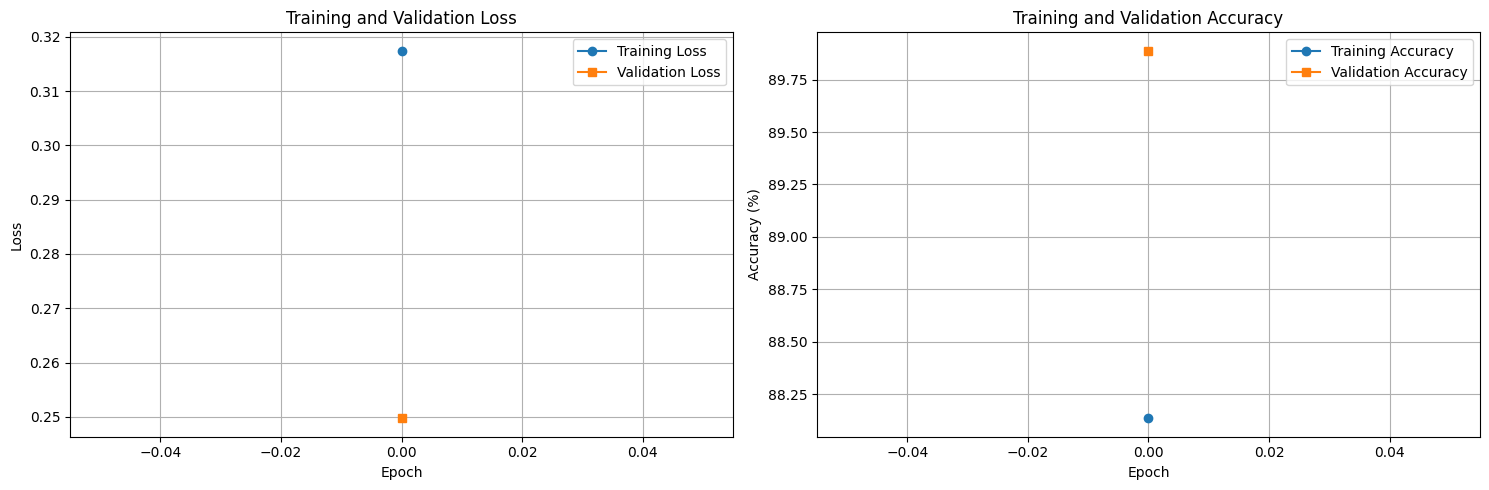


TRAINING COMPLETED SUCCESSFULLY!
Best model: deeplabv3_checkpoints/best_model_epoch_1.pth
Mean IoU: 0.7147
Device used: cuda


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.models.segmentation as models
import torch.nn.functional as F
from torchvision.models import ResNet50_Weights
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class DeepLabV3Segmentation:
    def __init__(self, num_classes, device='cuda', pretrained=True):
        """
        DeepLabV3 with ResNet50 backbone for image segmentation
        
        Args:
            num_classes: Number of segmentation classes (including background)
            device: Device to run on ('cuda' or 'cpu')
            pretrained: Whether to use pretrained weights
        """
        self.device = device
        self.num_classes = num_classes
        
        # Initialize model
        self.model = self._create_model(pretrained)
        # compile model
        # self.model = torch.compile(self.model, mode='max-autotune')
        self.model.to(self.device)
        
        # Training components
        self.optimizer = None
        self.criterion = None
        self.scheduler = None
        
        # Training history
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        
        print(f"DeepLabV3 ResNet50 initialized with {num_classes} classes")
        print(f"Model parameters: {sum(p.numel() for p in self.model.parameters()):,}")
        print(f"Trainable parameters: {sum(p.numel() for p in self.model.parameters() if p.requires_grad):,}")
    
    def _create_model(self, pretrained=True):
        """Create DeepLabV3 model with ResNet50 backbone"""
        if pretrained:
            # Load pretrained model
            model = models.deeplabv3_resnet50(weights='DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1')
            
            # Modify classifier for custom number of classes
            model.classifier[4] = nn.Conv2d(256, self.num_classes, kernel_size=1)
            model.aux_classifier[4] = nn.Conv2d(256, self.num_classes, kernel_size=1)
            
            print("Using pretrained DeepLabV3 ResNet50 weights (COCO+VOC)")
        else:
            # Create model from scratch
            model = models.deeplabv3_resnet50(weights=None, num_classes=self.num_classes)
            print("Created DeepLabV3 ResNet50 from scratch")
        
        return model
    
    def setup_training(self, learning_rate=1e-4, weight_decay=1e-5, class_weights=None):
        """Setup optimizer, loss function, and scheduler"""
        
        # Optimizer
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
        
        # Loss function
        if class_weights is not None:
            # Ensure class weights tensor has correct size
            if len(class_weights) != self.num_classes:
                print(f"Warning: Class weights size ({len(class_weights)}) doesn't match num_classes ({self.num_classes})")
                print("Creating properly sized class weights tensor...")
                
                # Create new tensor with correct size
                new_weights = torch.ones(self.num_classes)
                for i in range(min(len(class_weights), self.num_classes)):
                    new_weights[i] = class_weights[i]
                class_weights = new_weights
            
            class_weights = class_weights.to(self.device)
            print(f"  Class weights shape: {class_weights.shape}")
            print(f"  Class weights values: {class_weights}")
        
        self.criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=255)
        
        # Learning rate scheduler
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=5,
        )
        
        print(f"Training setup complete:")
        print(f"  Learning rate: {learning_rate}")
        print(f"  Weight decay: {weight_decay}")
        print(f"  Class weights: {'Enabled' if class_weights is not None else 'Disabled'}")
        print(f"  Number of classes: {self.num_classes}")
    
    def train_epoch(self, train_loader):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0.0
        correct_pixels = 0
        total_pixels = 0
        
        progress_bar = tqdm(train_loader, desc="Training")
        
        for batch_idx, batch in enumerate(progress_bar):
            images = batch['image'].to(self.device)
            masks = batch['mask'].to(self.device)
            
            # Debug: Check data shapes and values
            if batch_idx == 0:
                print(f"\nDebug - First batch:")
                print(f"  Images shape: {images.shape}")
                print(f"  Masks shape: {masks.shape}")
                print(f"  Unique mask values: {torch.unique(masks)}")
                print(f"  Mask dtype: {masks.dtype}")
            
            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(images)
            
            # Debug: Check output shapes
            if batch_idx == 0:
                print(f"  Output 'out' shape: {outputs['out'].shape}")
                print(f"  Output 'aux' shape: {outputs['aux'].shape}")
            
            # Calculate loss (main output + auxiliary output)
            main_loss = self.criterion(outputs['out'], masks)
            aux_loss = self.criterion(outputs['aux'], masks)
            loss = main_loss + 0.4 * aux_loss  # Standard auxiliary loss weight
            
            # Backward pass
            loss.backward()
            self.optimizer.step()
            
            # Statistics
            total_loss += loss.item()
            predicted = torch.argmax(outputs['out'], dim=1)
            correct_pixels += (predicted == masks).sum().item()
            total_pixels += masks.numel()
            
            # Update progress bar
            avg_loss = total_loss / (batch_idx + 1)
            accuracy = correct_pixels / total_pixels * 100
            progress_bar.set_postfix({
                'Loss': f'{avg_loss:.4f}',
                'Acc': f'{accuracy:.2f}%'
            })
        
        epoch_loss = total_loss / len(train_loader)
        epoch_accuracy = correct_pixels / total_pixels * 100
        
        return epoch_loss, epoch_accuracy
    
    def validate_epoch(self, val_loader):
        """Validate for one epoch"""
        self.model.eval()
        total_loss = 0.0
        correct_pixels = 0
        total_pixels = 0
        
        with torch.no_grad():
            progress_bar = tqdm(val_loader, desc="Validation")
            
            for batch_idx, batch in enumerate(progress_bar):
                images = batch['image'].to(self.device)
                masks = batch['mask'].to(self.device)
                
                # Forward pass
                outputs = self.model(images)
                
                # Calculate loss
                main_loss = self.criterion(outputs['out'], masks)
                aux_loss = self.criterion(outputs['aux'], masks)
                loss = main_loss + 0.4 * aux_loss
                
                # Statistics
                total_loss += loss.item()
                predicted = torch.argmax(outputs['out'], dim=1)
                correct_pixels += (predicted == masks).sum().item()
                total_pixels += masks.numel()
                
                # Update progress bar
                avg_loss = total_loss / (batch_idx + 1)
                accuracy = correct_pixels / total_pixels * 100
                progress_bar.set_postfix({
                    'Loss': f'{avg_loss:.4f}',
                    'Acc': f'{accuracy:.2f}%'
                })
        
        epoch_loss = total_loss / len(val_loader)
        epoch_accuracy = correct_pixels / total_pixels * 100
        
        return epoch_loss, epoch_accuracy
    
    def train(self, train_loader, val_loader, epochs=50, save_dir='checkpoints'):
        """Train the model"""
        os.makedirs(save_dir, exist_ok=True)
        
        best_val_loss = float('inf')
        best_model_path = None
        
        print(f"\nStarting training for {epochs} epochs...")
        print(f"Device: {self.device}")
        print(f"Training samples: {len(train_loader.dataset)}")
        print(f"Validation samples: {len(val_loader.dataset)}")
        print("-" * 60)
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            
            # Training
            train_loss, train_acc = self.train_epoch(train_loader)
            
            # Validation
            val_loss, val_acc = self.validate_epoch(val_loader)
            
            # Learning rate scheduling
            self.scheduler.step(val_loss)
            
            # Save history
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)
            
            # Print epoch summary
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
            print(f"Learning Rate: {self.optimizer.param_groups[0]['lr']:.6f}")
            
            # Save best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_path = os.path.join(save_dir, f'best_model_epoch_{epoch+1}.pth')
                self.save_model(best_model_path, epoch, train_loss, val_loss)
                print(f"✓ New best model saved: {best_model_path}")
            
            # Save checkpoint every 10 epochs
            if (epoch + 1) % 10 == 0:
                checkpoint_path = os.path.join(save_dir, f'checkpoint_epoch_{epoch+1}.pth')
                self.save_model(checkpoint_path, epoch, train_loss, val_loss)
        
        print(f"\nTraining completed!")
        print(f"Best validation loss: {best_val_loss:.4f}")
        print(f"Best model saved at: {best_model_path}")
        
        # Save training history
        self.save_training_history(save_dir)
        
        return best_model_path
    
    def save_model(self, filepath, epoch, train_loss, val_loss):
        """Save model checkpoint"""
        torch.save({
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'num_classes': self.num_classes,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_accuracies': self.train_accuracies,
            'val_accuracies': self.val_accuracies,
        }, filepath)
    
    def load_model(self, filepath):
        """Load model checkpoint"""
        checkpoint = torch.load(filepath, map_location=self.device)
        
        self.model.load_state_dict(checkpoint['model_state_dict'])
        
        if self.optimizer:
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if self.scheduler:
            self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        self.train_losses = checkpoint.get('train_losses', [])
        self.val_losses = checkpoint.get('val_losses', [])
        self.train_accuracies = checkpoint.get('train_accuracies', [])
        self.val_accuracies = checkpoint.get('val_accuracies', [])
        
        print(f"Model loaded from {filepath}")
        print(f"Epoch: {checkpoint['epoch']}")
        print(f"Training loss: {checkpoint['train_loss']:.4f}")
        print(f"Validation loss: {checkpoint['val_loss']:.4f}")
    
    def predict(self, image_tensor):
        """Predict segmentation mask for a single image"""
        self.model.eval()
        
        with torch.no_grad():
            if len(image_tensor.shape) == 3:
                image_tensor = image_tensor.unsqueeze(0)  # Add batch dimension
            
            image_tensor = image_tensor.to(self.device)
            outputs = self.model(image_tensor)
            predictions = torch.argmax(outputs['out'], dim=1)
            
            return predictions.cpu().numpy()
    
    def predict_batch(self, data_loader):
        """Predict segmentation masks for a batch of images"""
        self.model.eval()
        predictions = []
        filenames = []
        
        with torch.no_grad():
            for batch in tqdm(data_loader, desc="Predicting"):
                images = batch['image'].to(self.device)
                outputs = self.model(images)
                batch_predictions = torch.argmax(outputs['out'], dim=1).cpu().numpy()
                
                predictions.extend(batch_predictions)
                filenames.extend(batch['filename'])
        
        return predictions, filenames
    
    def evaluate_iou(self, val_loader):
        """Calculate IoU (Intersection over Union) for each class"""
        self.model.eval()
        
        class_ious = np.zeros(self.num_classes)
        class_counts = np.zeros(self.num_classes)
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Evaluating IoU"):
                images = batch['image'].to(self.device)
                masks = batch['mask'].to(self.device)
                
                outputs = self.model(images)
                predictions = torch.argmax(outputs['out'], dim=1)
                
                # Calculate IoU for each class
                for class_id in range(self.num_classes):
                    pred_mask = (predictions == class_id)
                    true_mask = (masks == class_id)
                    
                    intersection = (pred_mask & true_mask).sum().item()
                    union = (pred_mask | true_mask).sum().item()
                    
                    if union > 0:
                        class_ious[class_id] += intersection / union
                        class_counts[class_id] += 1
        
        # Average IoU per class
        mean_ious = np.divide(class_ious, class_counts, 
                             out=np.zeros_like(class_ious), where=class_counts!=0)
        
        # Overall mean IoU
        mean_iou = np.mean(mean_ious[class_counts > 0])
        
        print("\nIoU Evaluation Results:")
        for i, iou in enumerate(mean_ious):
            if class_counts[i] > 0:
                print(f"Class {i}: {iou:.4f}")
        print(f"Mean IoU: {mean_iou:.4f}")
        
        return mean_ious, mean_iou
    
    def plot_training_history(self, save_path=None):
        """Plot training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss plot
        ax1.plot(self.train_losses, label='Training Loss', marker='o')
        ax1.plot(self.val_losses, label='Validation Loss', marker='s')
        ax1.set_title('Training and Validation Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True)
        
        # Accuracy plot
        ax2.plot(self.train_accuracies, label='Training Accuracy', marker='o')
        ax2.plot(self.val_accuracies, label='Validation Accuracy', marker='s')
        ax2.set_title('Training and Validation Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy (%)')
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Training history plot saved to {save_path}")
        
        plt.show()
    
    def save_training_history(self, save_dir):
        """Save training history to JSON"""
        history = {
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_accuracies': self.train_accuracies,
            'val_accuracies': self.val_accuracies,
            'timestamp': datetime.now().isoformat()
        }
        
        history_path = os.path.join(save_dir, 'training_history.json')
        with open(history_path, 'w') as f:
            json.dump(history, f, indent=2)
        
        print(f"Training history saved to {history_path}")

# Example usage and training script
if __name__ == "__main__":
    # Import your dataset classes (assuming they're in the same file or imported)
    # from dataset import create_data_loaders_with_split, analyze_dataset, calculate_class_weights
    
    # Configuration
    CONFIG = {
        'image_dir': "/home/eyhyd/signature_comparison_project/signver/datasets/cropped_images",
        'mask_dir': "/home/eyhyd/signature_comparison_project/signver/datasets/cleaned_masks",
        'num_classes': 2,  # Adjust based on your dataset (background + signature)
        'batch_size': 8,  # Adjust based on your GPU memory
        'image_size': (512, 512),
        'learning_rate': 1e-4,
        'epochs': 1,
        'val_split': 0.25,
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'signature_mode': True  # Enable for signature dataset
    }
    
    print("="*60)
    print("DeepLabV3 ResNet50 Segmentation Training")
    print("="*60)
    
    # 1. Create data loaders
    print("1. Loading dataset...")
    train_loader, val_loader, train_dataset, val_dataset = create_data_loaders_with_split(
        CONFIG['image_dir'], CONFIG['mask_dir'],
        val_split=CONFIG['val_split'],
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        signature_mode=CONFIG['signature_mode']
    )
    
    # 2. Analyze dataset and calculate class weights
    print("\n2. Analyzing dataset...")
    class_counts = analyze_dataset(train_dataset)
    class_weights = calculate_class_weights(class_counts)
    
    # Debug: Check class information
    print(f"\nDebug Info:")
    print(f"  Classes found in dataset: {sorted(class_counts.keys())}")
    print(f"  Number of classes in CONFIG: {CONFIG['num_classes']}")
    print(f"  Class weights tensor size: {len(class_weights)}")
    
    # Ensure class weights match expected number of classes
    if len(class_weights) != CONFIG['num_classes']:
        print(f"  Adjusting class weights to match CONFIG['num_classes']...")
        new_weights = torch.ones(CONFIG['num_classes'])
        for i in range(min(len(class_weights), CONFIG['num_classes'])):
            new_weights[i] = class_weights[i]
        class_weights = new_weights
        print(f"  Adjusted class weights: {class_weights}")
    
    # 3. Initialize model
    print(f"\n3. Initializing DeepLabV3 model...")
    model = DeepLabV3Segmentation(
        num_classes=CONFIG['num_classes'],
        device=CONFIG['device'],
        pretrained=True
    )
    
    # 4. Setup training
    print("\n4. Setting up training...")
    model.setup_training(
        learning_rate=CONFIG['learning_rate'],
        class_weights=class_weights
    )
    
    # 5. Train model
    print("\n5. Starting training...")
    best_model_path = model.train(
        train_loader, val_loader,
        epochs=CONFIG['epochs'],
        save_dir='deeplabv3_checkpoints'
    )
    
    # 6. Evaluate model
    print("\n6. Evaluating model...")
    mean_ious, mean_iou = model.evaluate_iou(val_loader)
    
    # 7. Plot training history
    print("\n7. Plotting training history...")
    model.plot_training_history('training_history.png')
    
    print("\n" + "="*60)
    print("TRAINING COMPLETED SUCCESSFULLY!")
    print("="*60)
    print(f"Best model: {best_model_path}")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Device used: {CONFIG['device']}")
    print("="*60)

/home/eyhyd/signs_comparison/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SINGLE IMAGE PREDICTION
🚀 Starting prediction...
Loading checkpoint from: deeplabv3_checkpoints/best_model_epoch_1.pth
✓ Model loaded successfully
✓ Device: cuda
✓ Classes: 2
✓ Epoch: 0
✓ Validation loss: 0.2497
✓ Visualization saved to: prediction_result_original_size.png


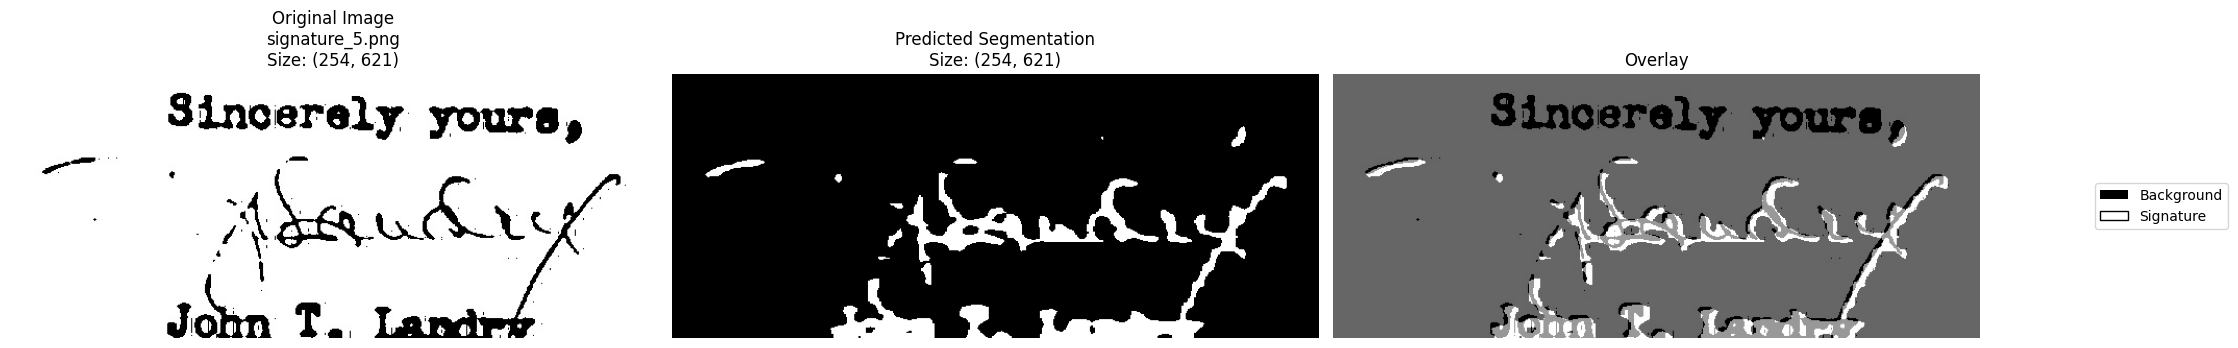


📊 Prediction Statistics:
Original image size: (254, 621)
Prediction size: (254, 621)
Unique prediction values: [0 1]
Background: 144,663 pixels (91.7%)
Signature: 13,071 pixels (8.3%)
✅ Prediction completed!


In [1]:
import torch
import torch.nn as nn
import torchvision.models.segmentation as models
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

class SignaturePredictor:
    def __init__(self, model_path, device='cuda'):
        """
        Simple predictor for signature segmentation
        
        Args:
            model_path: Path to the trained model checkpoint
            device: Device to run on ('cuda' or 'cpu')
        """
        self.device = device if torch.cuda.is_available() else 'cpu'
        
        # Load checkpoint to get model info
        print(f"Loading checkpoint from: {model_path}")
        checkpoint = torch.load(model_path, map_location=self.device)
        self.num_classes = checkpoint.get('num_classes', 2)
        
        # Create model (exactly as in training)
        self.model = self._create_model()
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.to(self.device)
        self.model.eval()
        
        # Preprocessing pipeline (EXACTLY as in training)
        self.transform = A.Compose([
            A.Resize(512, 512),
            A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # 3-channel normalization
            ToTensorV2(),
        ])
        
        print(f"✓ Model loaded successfully")
        print(f"✓ Device: {self.device}")
        print(f"✓ Classes: {self.num_classes}")
        print(f"✓ Epoch: {checkpoint.get('epoch', 'Unknown')}")
        print(f"✓ Validation loss: {checkpoint.get('val_loss', 'Unknown'):.4f}")
    
    def _create_model(self):
        """Create model architecture (exactly as in training)"""
        # Load pretrained DeepLabV3
        model = models.deeplabv3_resnet50(weights='DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1')
        
        # Modify for custom classes
        model.classifier[4] = nn.Conv2d(256, self.num_classes, kernel_size=1)
        model.aux_classifier[4] = nn.Conv2d(256, self.num_classes, kernel_size=1)
        
        return model
    
    def predict_image(self, image_path, return_original_size=True):
        """
        Predict segmentation mask for a single image
        
        Args:
            image_path: Path to input image
            return_original_size: If True, resize prediction back to original image size
            
        Returns:
            original_image: Original grayscale image
            prediction: Predicted segmentation mask
        """
        image_path = Path(image_path)
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")
        
        # Load image as color (as in training dataset)
        original_bgr = cv2.imread(str(image_path))
        if original_bgr is None:
            raise ValueError(f"Could not load image: {image_path}")
        
        # Store original dimensions
        original_height, original_width = original_bgr.shape[:2]
        
        # Convert BGR to RGB (as in training dataset)
        image_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
        
        # For display purposes, convert to grayscale
        original_gray = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2GRAY)
        
        # Apply same preprocessing as training (resizes to 512x512)
        transformed = self.transform(image=image_rgb)
        image_tensor = transformed['image'].unsqueeze(0).to(self.device)
        
        # Predict
        with torch.no_grad():
            outputs = self.model(image_tensor)
            prediction = torch.argmax(outputs['out'], dim=1).cpu().numpy()[0]
        
        # Resize prediction back to original size if requested
        if return_original_size:
            prediction = cv2.resize(
                prediction.astype(np.uint8), 
                (original_width, original_height), 
                interpolation=cv2.INTER_NEAREST  # Use nearest neighbor to preserve class labels
            )
        
        return original_gray, prediction
    
    def visualize_prediction(self, image_path, save_path=None, show_plot=True, original_size=True):
        """
        Predict and visualize segmentation
        
        Args:
            image_path: Path to input image
            save_path: Path to save visualization (optional)
            show_plot: Whether to display the plot
            original_size: If True, show results in original image size
        """
        # Get prediction
        original_image, prediction = self.predict_image(image_path, return_original_size=original_size)
        
        # Create binary colored mask (black background, white signature)
        colored_mask = np.zeros((*prediction.shape, 3))
        colored_mask[prediction == 0] = [0, 0, 0]  # Background = black
        colored_mask[prediction == 1] = [1, 1, 1]  # Signature = white (new fixed model)
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(20, 8))  # Increased figure size for original dimensions
        
        # Original image
        axes[0].imshow(original_image, cmap='gray')
        axes[0].set_title(f'Original Image\n{Path(image_path).name}\nSize: {original_image.shape}')
        axes[0].axis('off')
        
        # Prediction mask
        axes[1].imshow(colored_mask)
        axes[1].set_title(f'Predicted Segmentation\nSize: {prediction.shape}')
        axes[1].axis('off')
        
        # Overlay
        axes[2].imshow(original_image, cmap='gray')
        axes[2].imshow(colored_mask, alpha=0.6)
        axes[2].set_title('Overlay')
        axes[2].axis('off')
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='black', label='Background'),
            Patch(facecolor='white', label='Signature', edgecolor='black')
        ]
        fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.12, 0.5))
        
        plt.tight_layout()
        
        # Save if requested
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✓ Visualization saved to: {save_path}")
        
        # Show plot
        if show_plot:
            plt.show()
        else:
            plt.close()
        
        # Print statistics
        unique_classes, counts = np.unique(prediction, return_counts=True)
        total_pixels = prediction.size
        
        print(f"\n📊 Prediction Statistics:")
        print(f"Original image size: {original_image.shape}")
        print(f"Prediction size: {prediction.shape}")
        print(f"Unique prediction values: {unique_classes}")
        for class_id, count in zip(unique_classes, counts):
            percentage = count / total_pixels * 100
            class_name = "Background" if class_id == 0 else "Signature"
            print(f"{class_name}: {count:,} pixels ({percentage:.1f}%)")
        
        return original_image, prediction
    
    def predict_batch(self, input_dir, output_dir):
        """
        Predict multiple images in a directory
        
        Args:
            input_dir: Directory containing input images
            output_dir: Directory to save results
        """
        input_dir = Path(input_dir)
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Find all image files
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
        image_files = []
        for ext in image_extensions:
            image_files.extend(list(input_dir.glob(f'*{ext}')))
            image_files.extend(list(input_dir.glob(f'*{ext.upper()}')))
        
        print(f"Found {len(image_files)} images to process")
        
        # Process each image
        for i, image_path in enumerate(image_files, 1):
            print(f"\nProcessing {i}/{len(image_files)}: {image_path.name}")
            
            try:
                output_path = output_dir / f"{image_path.stem}_segmentation.png"
                self.visualize_prediction(
                    image_path, 
                    save_path=output_path,
                    show_plot=False  # Don't show plots for batch processing
                )
            except Exception as e:
                print(f"❌ Error processing {image_path}: {e}")
        
        print(f"\n✅ Batch processing completed! Results saved to {output_dir}")

def predict_single_image(model_path, image_path, output_path=None, original_size=True):
    """
    Convenience function to predict a single image
    
    Args:
        model_path: Path to trained model checkpoint
        image_path: Path to input image
        output_path: Path to save result (optional)
        original_size: If True, return results in original image size
    """
    print("🚀 Starting prediction...")
    
    # Initialize predictor
    predictor = SignaturePredictor(model_path)
    
    # Predict and visualize
    original, prediction = predictor.visualize_prediction(
        image_path, 
        save_path=output_path,
        show_plot=True,
        original_size=original_size
    )
    
    print("✅ Prediction completed!")
    return original, prediction

def predict_batch_images(model_path, input_dir, output_dir):
    """
    Convenience function to predict multiple images
    
    Args:
        model_path: Path to trained model
        input_dir: Directory containing input images
        output_dir: Directory to save results
    """
    print("🚀 Starting batch prediction...")
    
    # Initialize predictor
    predictor = SignaturePredictor(model_path)
    
    # Process batch
    predictor.predict_batch(input_dir, output_dir)
    
    print("✅ Batch prediction completed!")

# Example usage
if __name__ == "__main__":
    # Configuration
    MODEL_PATH = "deeplabv3_checkpoints/best_model_epoch_1.pth"  # Update this path
    
    # Example 1: Predict single image
    print("=" * 60)
    print("SINGLE IMAGE PREDICTION")
    print("=" * 60)
    
    predict_single_image(
        model_path=MODEL_PATH,
        image_path="/home/eyhyd/signature_comparison_project/signver/datasets/cropped_images/signature_5.png",
        output_path="prediction_result_original_size.png",
        original_size=True  # This will show results in original image dimensions
    )
    
    # Example 2: Batch prediction (uncomment to use)
    # print("\n" + "=" * 60)
    # print("BATCH PREDICTION")
    # print("=" * 60)
    # 
    # predict_batch_images(
    #     model_path=MODEL_PATH,
    #     input_dir="test_images/",
    #     output_dir="prediction_results/"
    # )
    
    # Example 3: Using predictor object directly for custom workflow
    # print("\n" + "=" * 60)
    # print("CUSTOM PREDICTION WORKFLOW")
    # print("=" * 60)
    # 
    # predictor = SignaturePredictor(MODEL_PATH)
    # 
    # # Predict multiple images with custom processing
    # test_images = [
    #     "signature_1.png",
    #     "signature_2.png", 
    #     "signature_3.png"
    # ]
    # 
    # for img_path in test_images:
    #     try:
    #         original, prediction = predictor.predict_image(img_path)
    #         print(f"Processed {img_path}: {np.sum(prediction == 1)} signature pixels")
    #     except Exception as e:
    #         print(f"Error with {img_path}: {e}")

SINGLE IMAGE PREDICTION
🚀 Starting prediction...
Loading checkpoint from: deeplabv3_checkpoints/best_model_epoch_1.pth
✓ Model loaded successfully
✓ Device: cuda
✓ Classes: 2
✓ Epoch: 0
✓ Validation loss: 0.2497
✓ Visualization saved to: prediction_result_original_size.png


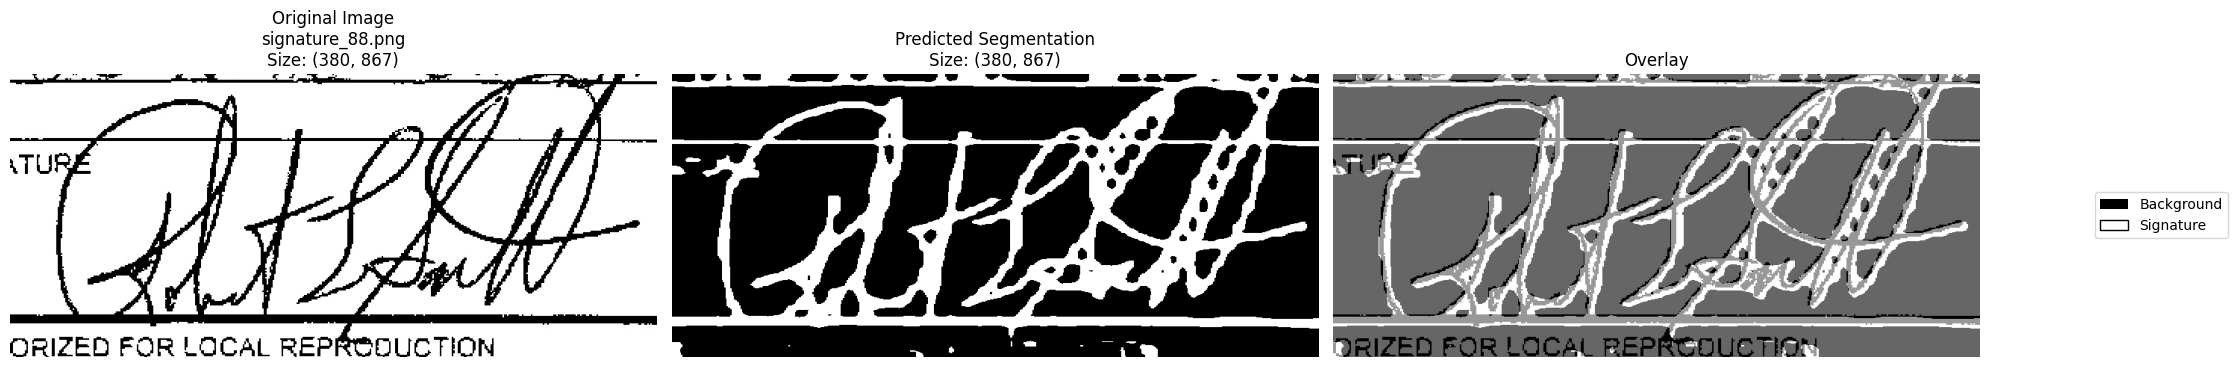


📊 Prediction Statistics:
Original image size: (380, 867)
Prediction size: (380, 867)
Unique prediction values: [0 1]
Background: 241,310 pixels (73.2%)
Signature: 88,150 pixels (26.8%)
✅ Prediction completed!


(array([[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [254, 255, 255, ..., 255, 255, 255],
        [254, 255, 255, ..., 255, 255, 255],
        [255, 254, 255, ..., 255, 255, 255]], dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], dtype=uint8))

In [6]:
# Configuration
MODEL_PATH = "deeplabv3_checkpoints/best_model_epoch_1.pth"  # Update this path

# Example 1: Predict single image
print("=" * 60)
print("SINGLE IMAGE PREDICTION")
print("=" * 60)

predict_single_image(
    model_path=MODEL_PATH,
    image_path="/home/eyhyd/signature_comparison_project/signver/datasets/cropped_images/signature_88.png",
    output_path="prediction_result_original_size.png",
    original_size=True  # This will show results in original image dimensions
)

SINGLE IMAGE PREDICTION
🚀 Starting prediction...
Loading checkpoint from: deeplabv3_checkpoints/best_model_epoch_1.pth
✓ Model loaded successfully
✓ Device: cuda
✓ Classes: 2
✓ Epoch: 0
✓ Validation loss: 0.2497
✓ Visualization saved to: prediction_result_original_size.png


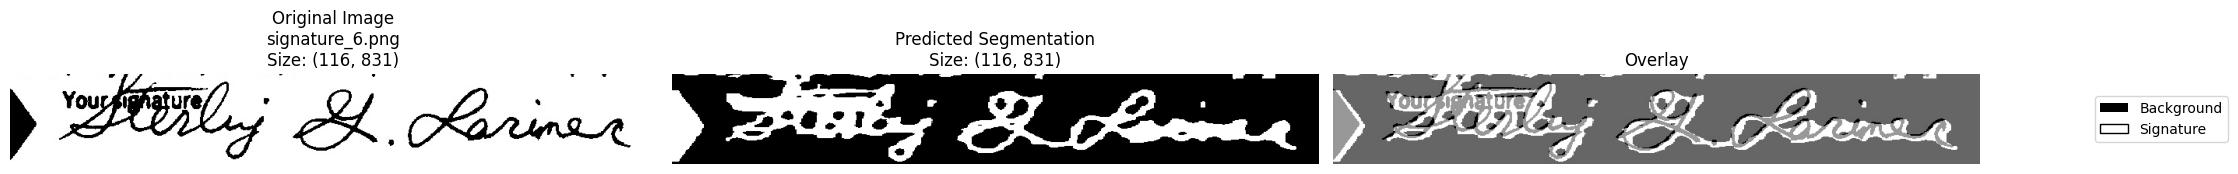


📊 Prediction Statistics:
Original image size: (116, 831)
Prediction size: (116, 831)
Unique prediction values: [0 1]
Background: 71,582 pixels (74.3%)
Signature: 24,814 pixels (25.7%)
✅ Prediction completed!


(array([[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]], dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

In [7]:
# Configuration
MODEL_PATH = "deeplabv3_checkpoints/best_model_epoch_1.pth"  # Update this path

# Example 1: Predict single image
print("=" * 60)
print("SINGLE IMAGE PREDICTION")
print("=" * 60)

predict_single_image(
    model_path=MODEL_PATH,
    image_path="/home/eyhyd/signature_comparison_project/signver/datasets/cropped_images/signature_6.png",
    output_path="prediction_result_original_size.png",
    original_size=True  # This will show results in original image dimensions
)

SINGLE IMAGE PREDICTION
🚀 Starting prediction...
Loading checkpoint from: deeplabv3_checkpoints/best_model_epoch_1.pth
✓ Model loaded successfully
✓ Device: cuda
✓ Classes: 2
✓ Epoch: 0
✓ Validation loss: 0.2497
✓ Visualization saved to: prediction_result_original_size.png


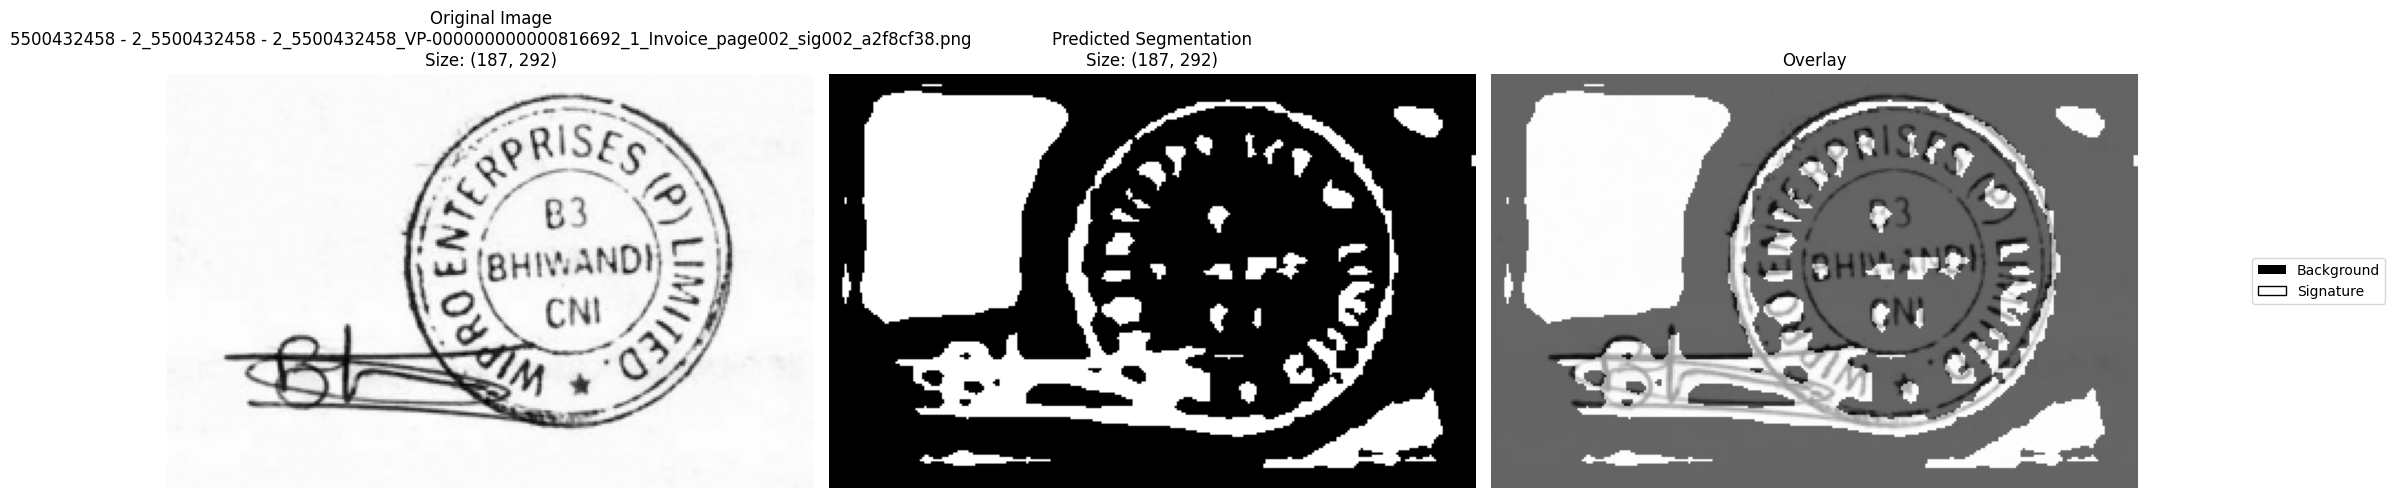


📊 Prediction Statistics:
Original image size: (187, 292)
Prediction size: (187, 292)
Unique prediction values: [0 1]
Background: 38,305 pixels (70.2%)
Signature: 16,299 pixels (29.8%)
✅ Prediction completed!


(array([[239, 239, 239, ..., 240, 241, 241],
        [239, 239, 239, ..., 240, 241, 241],
        [239, 239, 239, ..., 239, 240, 240],
        ...,
        [239, 239, 239, ..., 238, 238, 238],
        [239, 239, 239, ..., 237, 237, 237],
        [239, 239, 239, ..., 238, 238, 238]], dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

In [3]:
# Configuration
MODEL_PATH = "deeplabv3_checkpoints/best_model_epoch_1.pth"  # Update this path

# Example 1: Predict single image
print("=" * 60)
print("SINGLE IMAGE PREDICTION")
print("=" * 60)

predict_single_image(
    model_path=MODEL_PATH,
    image_path=r"/home/eyhyd/signs_comparison/signature_analysis_output/detected_signatures/5500432458 - 2_5500432458 - 2_5500432458_VP-000000000000816692_1_Invoice_page002_sig002_a2f8cf38.png",
    output_path="prediction_result_original_size.png",
    original_size=True  # This will show results in original image dimensions
)